<a href="https://colab.research.google.com/github/Maverick-Ansh/recurrent-depth-stepwise/blob/main/recurrent_depth_stepwise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Recurrent Depth (arXiv 2502.05171), built step by step
## Checkpoint 1: the Prelude **P** — tokens → latent space

The model is three groups: `e = P(x)`, then `s_i = R(e, s_{i-1})` looped r times, then `p = C(s_r)`.
This checkpoint builds only **P** exactly as Sec. 3.2 + 4.1 describe it, at the paper's real scale, and measures what the tokens look like in latent space when they come out.

Paper facts used here (nothing else):
| item | value | where |
|---|---|---|
| hidden h, heads | 5280, 55 × 96 | Sec 4.1 |
| MLP | gated SiLU, inner 17920 | Sec 3.2, 4.1 |
| layers in P | l_P = 2 (shape (2,4,2)) | Sec 3.1 |
| attention | causal, RoPE base 50000, bias on q and k only | Sec 3.2 |
| norm | RMSNorm, eps 1e-6, "sandwich" layout | Sec 3.2, 4.1 |
| vocab | 65536 BPE | Sec 4.1 |
| init | trunc-normal(±3σ), σ² = 2/(5h); out-projections σ² = 1/(5h·l), l = 132 | Sec 4.1 |
| embedding scale | γ = √h | Sec 4.1 |

Sandwich layer:  x̂ = n₂(x + Attn(n₁(x))),  x_out = n₄(x̂ + MLP(n₃(x̂)))

In [ ]:
# ── Setup ───────────────────────────────────────────────────────────────
import math, time, torch, torch.nn as nn, torch.nn.functional as F
from dataclasses import dataclass
import matplotlib.pyplot as plt  # test gggggggggggggggggggggggggggggggggggggggggggggggggfffffffffffff

DEV = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEV,
      "|", torch.cuda.get_device_name(0) if DEV == "cuda" else "")
if DEV == "cuda":
    free, tot = torch.cuda.mem_get_info(); print(f"GPU mem free {free/2**30:.1f} / {tot/2**30:.1f} GiB")

def show(fig, name):
    # small inline figure (keeps notebook light), full-res copy on disk
    fig.savefig(f"/content/{name}.png", dpi=130, bbox_inches="tight"); fig.set_dpi(44); plt.show()

torch 2.10.0+cu128 | device: cuda | Tesla T4
GPU mem free 14.5 / 14.6 GiB


In [ ]:
# ── Config: every number is from the paper (Sec 3.2 / 4.1). Edit freely for experiments. ──
@dataclass
class Cfg:
    vocab: int = 65536
    h: int = 5280                # hidden size
    n_heads: int = 55            # 55 x 96 = 5280
    mlp_inner: int = 17920       # gated SiLU inner dim
    l_P: int = 2                 # prelude layers
    l_R: int = 4                 # core layers (used later, needed for init depth l)
    l_C: int = 2                 # coda layers  (used later)
    r_bar: int = 32              # mean recurrence -> effective depth l = l_P + r_bar*l_R + l_C
    rope_base: float = 50000.0
    norm_eps: float = 1e-6
    max_seq: int = 4096
    @property
    def head_dim(self): return self.h // self.n_heads
    @property
    def l_eff(self): return self.l_P + self.r_bar * self.l_R + self.l_C
    @property
    def std_in(self):  return math.sqrt(2 / (5 * self.h))                 # sigma_h
    @property
    def std_out(self): return math.sqrt(1 / (5 * self.h * self.l_eff))    # sigma_out
    @property
    def emb_scale(self): return math.sqrt(self.h)                          # gamma

cfg = Cfg()
print(f"h={cfg.h}  heads={cfg.n_heads}x{cfg.head_dim}  effective depth l={cfg.l_eff}")
print(f"sigma_in = {cfg.std_in:.5f}   sigma_out = {cfg.std_out:.6f}   gamma = {cfg.emb_scale:.2f}")
print(f"=> per-entry std of gamma*E(x): {cfg.emb_scale*cfg.std_in:.4f}  (sqrt(2/5) = {math.sqrt(2/5):.4f}, same as s_0's sigma_s)")

h=5280  heads=55x96  effective depth l=132
sigma_in = 0.00870   sigma_out = 0.000536   gamma = 72.66
=> per-entry std of gamma*E(x): 0.6325  (sqrt(2/5) = 0.6325, same as s_0's sigma_s)


In [ ]:
# ── Building blocks ──────────────────────────────────────────────────────
def tnormal_(w, std):                        # truncated at +-3 sigma (Sec 4.1)
    return nn.init.trunc_normal_(w, mean=0.0, std=std, a=-3*std, b=3*std)

class RMSNorm(nn.Module):
    def __init__(s, d, eps):
        super().__init__(); s.eps = eps; s.weight = nn.Parameter(torch.ones(d))
    def forward(s, x):
        xf = x.float()
        return (xf * torch.rsqrt(xf.pow(2).mean(-1, keepdim=True) + s.eps)).to(x.dtype) * s.weight

def rope_tables(cfg, n, device):
    inv = 1.0 / (cfg.rope_base ** (torch.arange(0, cfg.head_dim, 2, device=device).float() / cfg.head_dim))
    ang = torch.outer(torch.arange(n, device=device).float(), inv)          # (n, d/2)
    return ang.cos(), ang.sin()

def apply_rope(x, cos, sin):                  # x: (B, H, n, d), rotate pairs (x1, x2)
    x1, x2 = x[..., ::2], x[..., 1::2]
    c, s = cos.to(x.dtype), sin.to(x.dtype)
    return torch.stack((x1 * c - x2 * s, x1 * s + x2 * c), -1).flatten(-2)

class Attention(nn.Module):
    def __init__(s, cfg):
        super().__init__(); s.cfg = cfg; h = cfg.h
        s.q = nn.Linear(h, h, bias=True)       # bias on q and k ONLY (Sec 3.2)
        s.k = nn.Linear(h, h, bias=True)
        s.v = nn.Linear(h, h, bias=False)
        s.o = nn.Linear(h, h, bias=False)      # out-projection -> sigma_out
    def forward(s, x, cos, sin):
        B, n, h = x.shape; H, d = s.cfg.n_heads, s.cfg.head_dim
        q, k, v = (m(x).view(B, n, H, d).transpose(1, 2) for m in (s.q, s.k, s.v))
        q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        return s.o(y.transpose(1, 2).reshape(B, n, h))

class GatedMLP(nn.Module):                     # SiLU(gate(x)) * up(x) -> down
    def __init__(s, cfg):
        super().__init__()
        s.gate = nn.Linear(cfg.h, cfg.mlp_inner, bias=False)
        s.up   = nn.Linear(cfg.h, cfg.mlp_inner, bias=False)
        s.down = nn.Linear(cfg.mlp_inner, cfg.h, bias=False)  # out-projection -> sigma_out
    def forward(s, x): return s.down(F.silu(s.gate(x)) * s.up(x))

class SandwichLayer(nn.Module):
    """x_hat = n2(x + Attn(n1(x)));  x_out = n4(x_hat + MLP(n3(x_hat)))"""
    def __init__(s, cfg):
        super().__init__()
        s.n1, s.n2, s.n3, s.n4 = (RMSNorm(cfg.h, cfg.norm_eps) for _ in range(4))
        s.attn, s.mlp = Attention(cfg), GatedMLP(cfg)
    def forward(s, x, cos, sin, rec=None, tag=""):
        a = s.attn(s.n1(x), cos, sin)
        x_hat = s.n2(x + a)
        m = s.mlp(s.n3(x_hat))
        x_out = s.n4(x_hat + m)
        if rec is not None:                    # record everything for inspection
            rec[f"{tag}.attn_out"] = a;  rec[f"{tag}.x_hat"] = x_hat
            rec[f"{tag}.mlp_out"]  = m;  rec[f"{tag}.x_out"] = x_out
        return x_out
        "Input → Attention + residual → RMSNorm → Gated MLP + residual → RMSNorm → Output."

class Prelude(nn.Module):
    """e = P(x): embed, scale by gamma, then l_P sandwich layers."""
    def __init__(s, cfg):
        super().__init__(); s.cfg = cfg
        s.E = nn.Embedding(cfg.vocab, cfg.h)
        s.layers = nn.ModuleList(SandwichLayer(cfg) for _ in range(cfg.l_P))
        s.reset_parameters()
    @torch.no_grad()
    def reset_parameters(s):
        for name, p in s.named_parameters():
            if p.dim() == 1:        # RMSNorm weights = 1, q/k biases = 0
                p.fill_(1.0) if "weight" in name else p.zero_()
            elif name.endswith(("attn.o.weight", "mlp.down.weight")):
                tnormal_(p, s.cfg.std_out)
            else:
                tnormal_(p, s.cfg.std_in)
    def forward(s, ids, record=False):
        rec = {} if record else None
        x = s.E(ids)
        if record: rec["E(x)"] = x
        x = x * s.cfg.emb_scale
        if record: rec["gE(x)"] = x
        cos, sin = rope_tables(s.cfg, ids.shape[1], ids.device)
        for i, L in enumerate(s.layers):
            x = L(x, cos, sin, rec, tag=f"L{i}")
        return (x, rec) if record else x
print("modules defined")

modules defined


In [ ]:
# ── Build P at full paper scale (fp32 on the T4: ~4.6 GB) ────────────────
torch.manual_seed(0)
t0 = time.time()
with torch.device(DEV):
    P = Prelude(cfg).eval()
torch.cuda.synchronize(); print(f"built in {time.time()-t0:.1f}s | GPU alloc {torch.cuda.memory_allocated()/2**30:.2f} GiB")

n_emb = P.E.weight.numel()
n_layer = sum(p.numel() for p in P.layers[0].parameters())
print(f"embedding      : {n_emb/1e6:8.1f} M")
print(f"one layer      : {n_layer/1e6:8.1f} M   (attn {sum(p.numel() for p in P.layers[0].attn.parameters())/1e6:.1f} M, "
      f"mlp {sum(p.numel() for p in P.layers[0].mlp.parameters())/1e6:.1f} M)")
print(f"prelude layers : {cfg.l_P*n_layer/1e6:8.1f} M")
print(f"paper check    : prelude+coda = 4 such layers = {4*n_layer/1e9:.2f} B  (paper: 'about 1.5B non-recurrent')")
print(f"                 embedding {n_emb/1e9:.3f} B  (paper: '0.5B in the tied input embedding')")

# init sanity: empirical std vs target
for nm, p, tgt in [("E", P.E.weight, cfg.std_in), ("L0.attn.q", P.layers[0].attn.q.weight, cfg.std_in),
                   ("L0.attn.o", P.layers[0].attn.o.weight, cfg.std_out), ("L0.mlp.down", P.layers[0].mlp.down.weight, cfg.std_out)]:
    print(f"  {nm:12s} std {p.std().item():.6f}  target {tgt:.6f} (trunc at 3σ shrinks it ~1.3%) | max|w|/σ = {p.abs().max().item()/tgt:.2f}")

built in 0.6s | GPU alloc 4.24 GiB
embedding      :    346.0 M
one layer      :    395.4 M   (attn 111.5 M, mlp 283.9 M)
prelude layers :    790.8 M
paper check    : prelude+coda = 4 such layers = 1.58 B  (paper: 'about 1.5B non-recurrent')
                 embedding 0.346 B  (paper: '0.5B in the tied input embedding')
  E            std 0.008587  target 0.008704 (trunc at 3σ shrinks it ~1.3%) | max|w|/σ = 3.00
  L0.attn.q    std 0.008587  target 0.008704 (trunc at 3σ shrinks it ~1.3%) | max|w|/σ = 3.00
  L0.attn.o    std 0.000528  target 0.000536 (trunc at 3σ shrinks it ~1.3%) | max|w|/σ = 3.00
  L0.mlp.down  std 0.000528  target 0.000536 (trunc at 3σ shrinks it ~1.3%) | max|w|/σ = 3.00


In [ ]:
# ── Tokenizer: the paper's own 65536-token BPE (only tokenizer.json, no model code / weights) ──
import os; os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "60"
from huggingface_hub import hf_hub_download
from transformers import PreTrainedTokenizerFast
tok_path = hf_hub_download("tomg-group-umd/huginn-0125", "tokenizer.json")
tok = PreTrainedTokenizerFast(tokenizer_file=tok_path, bos_token="<|begin_text|>")  # Sec 4.1: BOS on every document
BOS_ID = tok.bos_token_id
print("vocab size:", len(tok), "| fits cfg.vocab:", len(tok) <= cfg.vocab, "| BOS:", tok.bos_token, BOS_ID)
assert BOS_ID is not None and BOS_ID != tok.unk_token_id

def encode(text, bos=True):
    ids = tok(text, add_special_tokens=False)["input_ids"]
    return torch.tensor([([BOS_ID] if bos else []) + ids], device=DEV)

def pieces(ids): return [tok.decode([i]) for i in ids[0].tolist()]

ids = encode("The cat sat on the mat because the cat was tired.")
print(ids.shape[1], "tokens:", pieces(ids))

tokenizer.json: 0.00B [00:00, ?B/s]

vocab size: 65536 | fits cfg.vocab: True | BOS: <|begin_text|> 65504
13 tokens: ['<|begin_text|>', 'The', ' cat', ' sat', ' on', ' the', ' mat', ' because', ' the', ' cat', ' was', ' tired', '.']


### 1.1 Walk one sentence through P and measure every stage

Stages recorded: `E(x)` → `γE(x)` → per layer `attn_out`, `x̂`, `mlp_out`, `x_out`. The last `x_out` is **e**.

Per stage, over the n token vectors:
- **RMS**: per-entry size of each token vector
- **token corr**: mean cosine between vectors at different positions. This is the paper's collapse metric (Fig. 5: failed runs drove it to 1.0, so every position carried the same vector)
- **eff. rank**: participation ratio (Σσ²)² / Σσ⁴ of the n×h matrix, where σ are its singular values. It equals n when all directions are used evenly and 1 when collapsed
- **∠ to γE(x)**: how far (in degrees) each token has rotated away from its own raw embedding

**Prediction from the init alone:** σ_out² = 1/(5h·132), so each out-projection is about 70× smaller than the other weights. Attention output RMS ≈ √(h · 0.4 · σ_out²) ≈ 0.025, while x has RMS 0.63, so attention should change a token by only ~4% and the MLP by less. At init, e should be nearly a rescaled copy of the embedding.

In [ ]:
# ── Stage-by-stage latent statistics ─────────────────────────────────────
def cos_matrix(X):                       # X: (n, h) -> (n, n)
    Xn = F.normalize(X.float(), dim=-1); return Xn @ Xn.T

def stage_stats(X, ref=None, skip_bos=True):
    X = X[0].float()
    if skip_bos: X = X[1:]; ref = None if ref is None else ref[0, 1:].float()
    n = X.shape[0]; C = cos_matrix(X)
    tokcorr = (C.sum() - n) / (n * (n - 1))
    s2 = torch.linalg.svdvals(X).pow(2); pr = s2.sum()**2 / s2.pow(2).sum()
    ang = float("nan") if ref is None else torch.rad2deg(torch.acos(
        F.cosine_similarity(X, ref, dim=-1).clamp(-1, 1))).mean().item()
    return dict(rms=X.pow(2).mean(-1).sqrt().mean().item(), tokcorr=tokcorr.item(), pr=pr.item(), n=n, ang=ang)

@torch.no_grad()
def report(text):
    ids = encode(text); e, rec = P(ids, record=True); ref = rec["gE(x)"]
    print(f"{ids.shape[1]} tokens (stats exclude BOS)\n{'stage':14s} {'RMS':>8s} {'token corr':>11s} {'eff.rank':>9s} {'∠ to γE(x)':>11s}")
    for k, X in rec.items():
        st = stage_stats(X, ref)
        print(f"{k:14s} {st['rms']:8.4f} {st['tokcorr']:11.4f} {st['pr']:6.2f}/{st['n']:<2d} {st['ang']:10.3f}°")
    print("\nrelative update size  ||Δ|| / ||input||  (mean over tokens):")
    for i in range(cfg.l_P):
        x_in = rec["gE(x)"] if i == 0 else rec[f"L{i-1}.x_out"]
        ra = (rec[f"L{i}.attn_out"].norm(dim=-1) / x_in.norm(dim=-1))[0, 1:].mean().item()
        rm = (rec[f"L{i}.mlp_out"].norm(dim=-1) / rec[f"L{i}.x_hat"].norm(dim=-1))[0, 1:].mean().item()
        print(f"  L{i}: attention {ra*100:6.3f} %   MLP {rm*100:6.3f} %")
    return ids, e, rec

ids, e, rec = report("The cat sat on the mat because the cat was tired.")

13 tokens (stats exclude BOS)
stage               RMS  token corr  eff.rank  ∠ to γE(x)
E(x)             0.0085      0.0317   8.94/12      0.004°
gE(x)            0.6212      0.0317   8.94/12      0.008°
L0.attn_out      0.0108      0.6791   2.08/12     89.967°
L0.x_hat         1.0000      0.0318   8.98/12      0.993°
L0.mlp_out       0.0153      0.0303   8.82/12     90.045°
L0.x_out         1.0000      0.0318   8.98/12      1.332°
L1.attn_out      0.0109      0.6820   2.04/12     90.119°
L1.x_hat         1.0000      0.0319   8.98/12      1.470°
L1.mlp_out       0.0152      0.0324   8.92/12     90.096°
L1.x_out         1.0000      0.0319   8.98/12      1.712°

relative update size  ||Δ|| / ||input||  (mean over tokens):
  L0: attention  1.733 %   MLP  1.527 %
  L1: attention  1.093 %   MLP  1.523 %


### 1.2 Three probes of what P can and cannot know

1. **Context**: the same token id in different sentences. Before P its vector is identical (cos = 1). How far apart does P push the copies?
2. **Position**: a run of one repeated token. Attention mixes value vectors, and if every value is the same, any mix of them is that same vector, whatever the weights or RoPE angles. So without BOS the prelude cannot tell position k from position k+1. With BOS there is a second vector in the mix, and the share it gets shrinks as the run grows. That is the only position signal. Measure it.
3. **Causality**: change the last token and check that every earlier e stays bit-identical.

In [ ]:
torch.set_grad_enabled(False)   # checkpoint 1 is inference only
# ── Probe 1: same token, different contexts ──────────────────────────────
def token_vecs(sentences, word):
    wid = tok(word, add_special_tokens=False)["input_ids"]; assert len(wid) == 1, (word, wid); wid = wid[0]
    out = []
    for s in sentences:
        ids = encode(s); e = P(ids)
        pos = (ids[0] == wid).nonzero().flatten().tolist()
        out += [(s, p, e[0, p]) for p in pos]
    return out

sents = ["I went to the bank to deposit money.",
         "The river bank was covered in mud.",
         "She works at a bank downtown.",
         "Fish swim near the bank of the lake.",
         "Rob the bank tonight, he said, and the bank will never know."]
vs = token_vecs(sents, " bank")
V = torch.stack([v for *_, v in vs])
C = cos_matrix(V); n = len(vs)
print(f"' bank' occurrences: {n}")
print(f"cos between the SAME token in different contexts: mean {((C.sum()-n)/(n*(n-1))).item():.5f}, min {C.min().item():.5f}")
O = torch.cat([P(encode(s))[0, 1:] for s in sents]); Co = cos_matrix(O); m = O.shape[0]
print(f"cos between DIFFERENT positions (any tokens):    mean {((Co.sum()-m)/(m*(m-1))).item():.5f}")

# ── Probe 2: position from a repeated token ──────────────────────────────
def repeat_probe(word=" the", k=40, bos=True):
    wid = tok(word, add_special_tokens=False)["input_ids"][0]
    ids = torch.tensor([([tok.bos_token_id] if bos else []) + [wid]*k], device=DEV)
    e = P(ids)[0, (1 if bos else 0):]
    return (e - e[0]).norm(dim=-1) / e[0].norm()           # distance from the first copy
d_nobos, d_bos = repeat_probe(bos=False), repeat_probe(bos=True)
print(f"\nrepeated ' the' x40, NO BOS : max ||e_k - e_1||/||e_1|| = {d_nobos.max().item():.2e}  (fp noise only)")
print(f"repeated ' the' x40, WITH BOS: ||e_k - e_1||/||e_1|| at k=2,5,10,40 = "
      + ", ".join(f"{d_bos[k-1].item():.4f}" for k in (2, 5, 10, 40)))

# ── Probe 3: causality ───────────────────────────────────────────────────
a, b = encode("The cat sat on the mat."), encode("The cat sat on the dog.")
assert a.shape == b.shape and (a != b).sum() == 1
j = (a != b).nonzero()[0, 1].item()
diff = (P(a) - P(b)).abs().amax(-1)[0]
print(f"\ncausality: edit at position {j}; max|Δe| before it = {diff[:j].max().item():.1e}, at it = {diff[j].item():.3f}, after = {diff[j+1:].max().item():.3f}")

' bank' occurrences: 6
cos between the SAME token in different contexts: mean 0.99977, min 0.99971
cos between DIFFERENT positions (any tokens):    mean 0.03202

repeated ' the' x40, NO BOS : max ||e_k - e_1||/||e_1|| = 4.25e-08  (fp noise only)
repeated ' the' x40, WITH BOS: ||e_k - e_1||/||e_1|| at k=2,5,10,40 = 0.0101, 0.0217, 0.0267, 0.0316

causality: edit at position 6; max|Δe| before it = 0.0e+00, at it = 5.078, after = 0.036


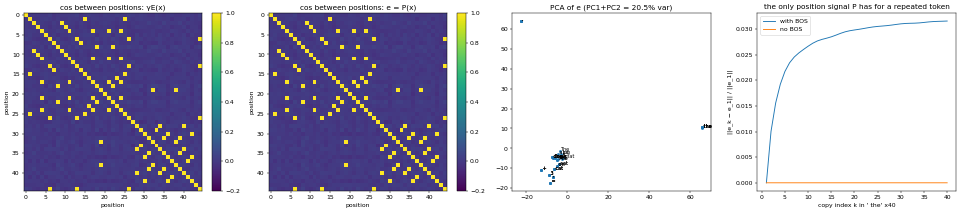

In [ ]:
# ── Pictures of the latent space ─────────────────────────────────────────
para = ("The cat sat on the mat. The dog sat on the log. The cat saw the dog, "
        "and the dog saw the cat. 1 + 2 = 3, 2 + 3 = 5, 3 + 5 = 8.")
ids_p = encode(para); e_p, rec_p = P(ids_p, record=True); lab = pieces(ids_p)

fig, ax = plt.subplots(1, 4, figsize=(22, 5))
for a_, key, title in [(ax[0], "gE(x)", "cos between positions: γE(x)"), (ax[1], "L1.x_out", "cos between positions: e = P(x)")]:
    im = a_.imshow(cos_matrix(rec_p[key][0, 1:]).cpu(), vmin=-0.2, vmax=1, cmap="viridis")
    a_.set_title(title); a_.set_xlabel("position"); a_.set_ylabel("position"); fig.colorbar(im, ax=a_, fraction=0.046)

# PCA of e (BOS excluded): identical token ids should land on (almost) the same point
X = e_p[0, 1:].float(); X = X - X.mean(0)
U, S, Vh = torch.linalg.svd(X, full_matrices=False); Z = (X @ Vh[:2].T).cpu()
ax[2].scatter(Z[:, 0], Z[:, 1], s=12)
for i, t in enumerate(lab[1:]): ax[2].annotate(repr(t)[1:-1], Z[i], fontsize=8)
ax[2].set_title(f"PCA of e (PC1+PC2 = {(S[:2]**2).sum()/(S**2).sum()*100:.1f}% var)")

ax[3].plot(range(1, 41), d_bos.cpu(), label="with BOS"); ax[3].plot(range(1, 41), d_nobos.cpu(), label="no BOS")
ax[3].set_xlabel("copy index k in ' the' x40"); ax[3].set_ylabel("||e_k − e_1|| / ||e_1||")
ax[3].set_title("the only position signal P has for a repeated token"); ax[3].legend()
plt.tight_layout(); show(fig, "ckpt1_latent")

### Checkpoint 1 results (untrained P, paper init, h = 5280)

**1. At init, e is the embedding, normalised and turned by 1.7°.** No token moves more than about 2° from its own γE(x). The token correlation (0.032) and effective rank (8.98 of 12) are unchanged from E(x) to e. The 0.032 is not collapse. The sentence has two repeated tokens (`the`, `cat`), whose copies have cos 1, and 4 such ordered pairs out of 132 gives 4/132 = 0.030.

**2. My ~4% prediction was wrong. The measured attention update is 1.7%, and the reason is informative.** At init q and k are tiny, so the attention scores are nearly equal and every position takes the *mean* of the value vectors in its prefix. The mean of k roughly uncorrelated vectors shrinks by 1/√k. The unaveraged estimate is √h·σ_out × √h·σ_in = 0.038 × 0.62 ≈ 0.024. The mean of 1/√(i) over prefix lengths i = 2..13 is 0.41, giving ≈ 0.0098, against 0.0108 measured. That is the result predicted by uniform attention.

**3. The attention output is the one stage that looks collapsed** (token corr 0.68, eff. rank 2.1). This follows from point 2. Neighbouring positions average almost the same prefix, so their outputs are nearly equal. It is harmless here only because σ_out keeps the output small next to the residual.

**4. Scale: e has RMS 1.0, not 0.63.** The final n₄ RMSNorm fixes it at 1. The paper samples s₀ with σ_s = √(2/5) ≈ 0.63 "to match" the embedding. That matches γE(x) (0.62) but *not* e, which is what R actually receives. **This is an open question for Checkpoint 2:** R concatenates [s, e], so at step 1 the two halves arrive at different scales.

**5. Context:** the six occurrences of ` bank` have cos 0.9998 with each other. The untrained P barely separates contexts. Any separation must come from training.

**6. Position:** with no BOS, 40 copies of ` the` give *identical* e (difference 4e-8, fp noise). This holds for any weights. With BOS the copies drift slowly (1% at k=2, 3.2% at k=40), and the BOS share of the average is the only position signal. RoPE on its own gives none, because it only reweights identical value vectors.

**7. Causality:** changing one token leaves every earlier e bit-identical (max |Δ| = 0).

**Paper check:** 4 sandwich layers = 1.58 B, which matches the paper's "~1.5B non-recurrent". The embedding is 65536 × 5280 = **0.346 B**, while the paper says 0.5B, so that figure in the paper is loose.

## Checkpoint 2: the recurrent block **R**

From Sec. 3.2 and 4.1:

  s₀ ~ TruncNormal(0, σ_s²), σ_s² = 2/5  s_i = R(e, s_{i−1}) = n_c( L₄ ∘ L₃ ∘ L₂ ∘ L₁ ( A·[s_{i−1} ; e] ) )

- **A** is the adapter, a 2h → h linear map applied to the concatenation [s ; e]. It is initialised like every other non-out-projection weight.
- L₁..L₄ are the same sandwich layers as in P (l_R = 4). n_c is a final RMSNorm.
- The same R (same weights) is applied r times, and **e is fed in again at every step**.

**Predictions before running anything.** Split A = [A_s | A_e], so A·[s; e] = A_s·s + A_e·e.
- **P1, step-1 scale.** At init, each of A_s·s and A_e·e has RMS σ√h × RMS(input). At step 1, RMS(s₀) ≈ 0.62 and RMS(e) = 1, so e carries 1/(1+0.62²) ≈ **72%** of the adapter's output power. From step 2 on, s has RMS 1 (n_c fixes it), so the split is **50/50**.
- **P2, contraction at init.** The out-projections are tiny, so the 4 layers do little and R(e,s) ≈ rmsnorm(A_s·s + A_e·e). The Jacobian with respect to s is (1/RMS(y))·(projection)·A_s. The spectral radius of a random Gaussian A_s is σ√h, and RMS(y) = σ√h·√2. So two trajectories started from different s₀ should close in at a rate of **1/√2 ≈ 0.707 per step**. This rate does not depend on σ or h.
- **P3, injection strength.** Scale e by α before it enters A, and the rate becomes **1/√(1+α²)**. At α = 0 (no injection) the rate is 1 and the iteration does not forget s₀. This is the paper's footnote-1 claim that without e the process is not stable, turned into a number.
- **P4, per token.** e has RMS exactly 1 at every position (n₄), so the rate should be the **same for every token**.

In [ ]:
# ── The core block R ─────────────────────────────────────────────────────
@torch.no_grad()
def paper_init_(module, cfg):
    for name, p in module.named_parameters():
        if p.dim() == 1:
            p.fill_(1.0) if "weight" in name else p.zero_()
        elif name.endswith(("attn.o.weight", "mlp.down.weight")):
            tnormal_(p, cfg.std_out)
        else:
            tnormal_(p, cfg.std_in)

class Core(nn.Module):
    """R(e, s) = n_c( L_lR(...L_1( A [s ; e] )) )"""
    def __init__(s, cfg):
        super().__init__(); s.cfg = cfg
        s.A = nn.Linear(2 * cfg.h, cfg.h, bias=False)      # adapter 2h -> h
        s.layers = nn.ModuleList(SandwichLayer(cfg) for _ in range(cfg.l_R))
        s.n_c = RMSNorm(cfg.h, cfg.norm_eps)
        paper_init_(s, cfg)
    def forward(s, e, state, cos, sin):
        x = s.A(torch.cat([state, e], dim=-1))
        for L in s.layers:
            x = L(x, cos, sin)
        return s.n_c(x)

def sample_s0(shape, seed, std=math.sqrt(2 / 5), device=DEV):      # sigma_s^2 = 2/5 (Sec 4.1)
    g = torch.Generator(device=device).manual_seed(seed)
    return nn.init.trunc_normal_(torch.empty(shape, device=device), 0.0, std, -3*std, 3*std, generator=g)

torch.manual_seed(1)
with torch.device(DEV):
    R = Core(cfg).eval()
torch.cuda.synchronize()
nR = sum(p.numel() for p in R.parameters())
print(f"core R: {nR/1e9:.3f} B params  (adapter {R.A.weight.numel()/1e6:.1f} M + {cfg.l_R} layers)   paper: '1.5B in the core'")
print(f"GPU alloc now {torch.cuda.memory_allocated()/2**30:.2f} GiB (P + R, fp32)")
print(f"A std {R.A.weight.std().item():.6f} (target {cfg.std_in:.6f}),  sigma*sqrt(h) = {R.A.weight.std().item()*math.sqrt(cfg.h):.4f}")
s0 = sample_s0((1, 8, cfg.h), seed=0)
print(f"s0: std {s0.std().item():.4f} (sigma_s {math.sqrt(2/5):.4f}, trunc shrinks ~1.3%), max|s0|/sigma_s = {s0.abs().max().item()/math.sqrt(2/5):.2f}")

core R: 1.637 B params  (adapter 55.8 M + 4 layers)   paper: '1.5B in the core'
GPU alloc now 10.36 GiB (P + R, fp32)
A std 0.008586 (target 0.008704),  sigma*sqrt(h) = 0.6239
s0: std 0.6244 (sigma_s 0.6325, trunc shrinks ~1.3%), max|s0|/sigma_s = 3.00


In [ ]:
# ── The recurrence loop, instrumented ────────────────────────────────────
H = cfg.h
@torch.no_grad()
def recur(e, r, s0, alpha=1.0):
    """Run s_i = R(alpha*e, s_{i-1}) for i=1..r. Returns states (r+1, B, n, h) and the per-step
    share of the adapter's output power that comes from e: ||A_e e||^2 / (||A_s s||^2 + ||A_e e||^2)."""
    cos, sin = rope_tables(cfg, e.shape[1], e.device)
    As, Ae = R.A.weight[:, :H], R.A.weight[:, H:]
    ein = alpha * e
    pe = (ein @ Ae.T).pow(2).sum(-1)                       # fixed across steps
    s, states, eshare = s0, [s0], []
    for _ in range(r):
        ps = (s @ As.T).pow(2).sum(-1)
        eshare.append(pe / (ps + pe))
        s = R(ein, s, cos, sin); states.append(s)
    return torch.stack(states), torch.stack(eshare)

def rel(a, b):   # ||a-b|| / ||a|| per token
    return (a - b).norm(dim=-1) / a.norm(dim=-1)

def fit_rate(g, lo=2, floor=1e-4):
    """Geometric decay rate of a positive sequence g[i] (1-D), fit by log-linear regression on
    steps i >= lo while g > floor (above the fp32 noise floor)."""
    g = g.detach().double().cpu()
    idx = [i for i in range(lo, len(g)) if g[i] > floor]
    if len(idx) < 3: return float("nan")
    x = torch.tensor(idx, dtype=torch.float64); y = torch.log(g[idx])
    return math.exp(((x - x.mean()) * (y - y.mean())).sum() / ((x - x.mean())**2).sum())

# input: the Checkpoint-1 paragraph, e from P. Batch = 2 different random s0 (seeds 0, 1)
e2 = e_p.expand(2, -1, -1).contiguous()
n_tok = e2.shape[1]
s0 = torch.cat([sample_s0((1, n_tok, H), seed=0), sample_s0((1, n_tok, H), seed=1)])
torch.cuda.synchronize(); t0 = time.time()
r_max = 48
S, esh = recur(e2, r_max, s0)
torch.cuda.synchronize(); dt = (time.time() - t0) / r_max
print(f"{n_tok} tokens, batch 2, r={r_max}: {dt*1e3:.1f} ms per iteration  (effective depth at r=32: {cfg.l_eff} layers)")

46 tokens, batch 2, r=48: 142.8 ms per iteration  (effective depth at r=32: 132 layers)


In [ ]:
# ── 2.1 / 2.2: step-1 scale, convergence, path independence, per-token rate ──
tk = slice(1, None)                                        # exclude BOS from stats
step = torch.stack([rel(S[i, 0], S[i-1, 0]) for i in range(1, r_max + 1)])   # (r, n) seed-0 step size
gap  = torch.stack([rel(S[i, 0], S[i, 1])   for i in range(0, r_max + 1)])   # (r+1, n) seed-0 vs seed-1
rms  = S.pow(2).mean(-1).sqrt()                                              # (r+1, B, n)

print("P1: share of adapter output power from e   (predicted: step 1 = 1/(1+RMS(s0)^2), later 0.50)")
r0 = rms[0, 0, tk].mean().item()
print(f"    RMS(s0) = {r0:.4f} -> predicted step-1 share {1/(1+r0**2):.4f}")
for i in (1, 2, 3, 10, 48):
    print(f"    step {i:2d}: e-share {esh[i-1, 0, tk].mean().item():.4f}   RMS(s_{i-1}) = {rms[i-1, 0, tk].mean().item():.4f}")

print("\nP2: relative step ||s_i - s_{i-1}||/||s_i||  and seed gap ||s_i^a - s_i^b||/||s_i^a||  (mean over tokens)")
print(f"    {'i':>3s} {'step':>10s} {'seed gap':>10s} {'(1/sqrt2)^i':>12s}")
for i in (1, 2, 4, 8, 12, 16, 24, 32, 40, 48):
    print(f"    {i:3d} {step[i-1, tk].mean().item():10.2e} {gap[i, tk].mean().item():10.2e} {2**(-i/2):12.2e}")
rate_gap  = fit_rate(gap[:, tk].mean(-1))
rate_step = fit_rate(step[:, tk].mean(-1))
print(f"    fitted rate: seed gap {rate_gap:.4f}, step size {rate_step:.4f}   predicted 1/sqrt(2) = {1/math.sqrt(2):.4f}")

print("\nP4: per-token contraction rate (seed gap), one rate per token")
per_tok = torch.tensor([fit_rate(gap[:, j]) for j in range(1, n_tok)])
print(f"    mean {per_tok.mean():.4f}  std {per_tok.std():.4f}  min {per_tok.min():.4f}  max {per_tok.max():.4f}")
print(f"    BOS token rate: {fit_rate(gap[:, 0]):.4f}")

P1: share of adapter output power from e   (predicted: step 1 = 1/(1+RMS(s0)^2), later 0.50)
    RMS(s0) = 0.6235 -> predicted step-1 share 0.7201
    step  1: e-share 0.7197   RMS(s_0) = 0.6235
    step  2: e-share 0.4998   RMS(s_1) = 1.0000
    step  3: e-share 0.5016   RMS(s_2) = 1.0000
    step 10: e-share 0.5010   RMS(s_9) = 1.0000
    step 48: e-share 0.5009   RMS(s_47) = 1.0000

P2: relative step ||s_i - s_{i-1}||/||s_i||  and seed gap ||s_i^a - s_i^b||/||s_i^a||  (mean over tokens)
      i       step   seed gap  (1/sqrt2)^i
      1   1.18e+00   7.50e-01     7.07e-01
      2   8.95e-01   5.31e-01     5.00e-01
      4   4.46e-01   2.66e-01     2.50e-01
      8   1.12e-01   6.64e-02     6.25e-02
     12   2.78e-02   1.66e-02     1.56e-02
     16   6.98e-03   4.16e-03     3.91e-03
     24   4.44e-04   2.62e-04     2.44e-04
     32   2.81e-05   1.66e-05     1.53e-05
     40   1.96e-06   1.32e-06     9.54e-07
     48   6.50e-07   6.31e-07     5.96e-08
    fitted rate: seed gap 0.7074

In [ ]:
# ── 2.3: injection strength alpha (e -> alpha*e), predicted rate 1/sqrt(1+alpha^2) ──
alphas = [0.0, 0.25, 0.5, 1.0, 2.0, 4.0]
sweep = {}
for a in alphas:
    Sa, _ = recur(e2, 32, s0, alpha=a)
    g = torch.stack([rel(Sa[i, 0], Sa[i, 1]) for i in range(33)])[:, tk].mean(-1)
    sweep[a] = g.cpu()
    print(f"alpha {a:4.2f}: measured rate {fit_rate(g):.4f}   predicted {1/math.sqrt(1+a*a):.4f}   "
          f"seed gap at i=32: {g[32].item():.2e}")
del Sa

# what the state converges TO (alpha = 1): compare the fixed point with e (Checkpoint-1 stats)
s_star = S[r_max, 0:1]
print("\nfixed point s* (alpha=1, i=48) vs its input e:")
for nm, X in [("e", e_p), ("s*", s_star)]:
    st = stage_stats(X)
    print(f"  {nm:3s} RMS {st['rms']:.4f}  token corr {st['tokcorr']:.4f}  eff.rank {st['pr']:.2f}/{st['n']}")
c = F.cosine_similarity(s_star[0, 1:], e_p[0, 1:], dim=-1)
print(f"  cos(s*, e) per token: mean {c.mean().item():.4f}  (random vectors in R^5280: ~0 ± {1/math.sqrt(H):.4f})")
dup = [(i, j) for i in range(1, n_tok) for j in range(i+1, n_tok) if ids_p[0, i] == ids_p[0, j]]
dd = torch.tensor([rel(s_star[0, i], s_star[0, j]).item() for i, j in dup])
print(f"  same token id at different positions ({len(dup)} pairs): ||s*_i - s*_j||/||s*_i|| mean {dd.mean():.4f}, max {dd.max():.4f}")

alpha 0.00: measured rate 0.9997   predicted 1.0000   seed gap at i=32: 1.41e+00
alpha 0.25: measured rate 0.9708   predicted 0.9701   seed gap at i=32: 5.25e-01
alpha 0.50: measured rate 0.8951   predicted 0.8944   seed gap at i=32: 3.57e-02
alpha 1.00: measured rate 0.7074   predicted 0.7071   seed gap at i=32: 1.66e-05
alpha 2.00: measured rate 0.4476   predicted 0.4472   seed gap at i=32: 2.55e-07
alpha 4.00: measured rate 0.2429   predicted 0.2425   seed gap at i=32: 1.36e-07

fixed point s* (alpha=1, i=48) vs its input e:
  e   RMS 1.0000  token corr 0.0399  eff.rank 16.16/45
  s*  RMS 1.0000  token corr 0.0411  eff.rank 15.98/45
  cos(s*, e) per token: mean 0.0016  (random vectors in R^5280: ~0 ± 0.0138)
  same token id at different positions (40 pairs): ||s*_i - s*_j||/||s*_i|| mean 0.0152, max 0.0462


In [ ]:
# ── Use both T4s: an identical replica of R on each GPU, independent jobs run concurrently ──
import gc, sys, threading
for k in ("last_traceback", "last_value", "last_type", "last_exc"):   # drop any dead traceback pinning GPU memory
    if hasattr(sys, k): setattr(sys, k, None)
gc.collect(); torch.cuda.empty_cache()

NG = torch.cuda.device_count()
for d in range(NG):
    f, t = torch.cuda.mem_get_info(d); print(f"cuda:{d} {torch.cuda.get_device_name(d)}  free {f/2**30:.1f}/{t/2**30:.1f} GiB")
assert NG >= 2, "only one GPU visible"

R_on = {0: R}
if "R1" not in globals():
    with torch.device("cuda:1"):
        R1 = Core(cfg).eval()                           # built directly on GPU 1 (no GPU-0 staging copy)
    R1.load_state_dict(R.state_dict())                  # copy R's weights across devices
R_on[1] = R1
assert all(torch.equal(a.cpu(), b.cpu()) for a, b in zip(R.parameters(), R1.parameters())), "replica differs"

@torch.no_grad()
def recur_on(core, e, r, s0, alpha=1.0):
    """Same recurrence as recur() (without the e-share bookkeeping), on a given replica."""
    dev = next(core.parameters()).device
    e, s0 = e.to(dev), s0.to(dev)
    cos, sin = rope_tables(cfg, e.shape[1], dev)
    ein = alpha * e; s = s0; states = [s0]
    for _ in range(r):
        s = core(ein, s, cos, sin); states.append(s)
    return torch.stack(states)

def run_parallel(jobs):
    """jobs: list of (fn, kwargs); called as fn(core=replica, **kwargs). Job k runs on GPU k % NG,
    and the GPUs work concurrently (CUDA kernels release the GIL). Results come back in job order."""
    out = [None] * len(jobs)
    def worker(g):
        with torch.cuda.device(g):
            for k in range(g, len(jobs), NG):
                fn, kw = jobs[k]; out[k] = fn(core=R_on[g], **kw)
            torch.cuda.synchronize(g)
    th = [threading.Thread(target=worker, args=(g,)) for g in range(NG)]
    [t.start() for t in th]; [t.join() for t in th]
    return out

# speed check: 4 identical jobs, one GPU vs both
last = lambda core, **kw: recur_on(core, **kw)[-1].cpu()
job = (last, dict(e=e2, r=16, s0=s0))
t0 = time.time(); ref = [last(core=R, **job[1]) for _ in range(4)]; t1 = time.time() - t0
t0 = time.time(); res = run_parallel([job] * 4); t2 = time.time() - t0
print(f"4 jobs x r=16: one GPU {t1:.2f}s, two GPUs {t2:.2f}s  -> {t1/t2:.2f}x")
print("GPU-1 result == GPU-0 result bit-for-bit:", torch.equal(res[0], res[1]), "| == single-GPU run:", torch.equal(res[0], ref[0]))
for d in range(NG): print(f"cuda:{d} allocated {torch.cuda.memory_allocated(d)/2**30:.2f} GiB")

cuda:0 Tesla T4  free 0.2/14.6 GiB
cuda:1 Tesla T4  free 14.5/14.6 GiB
4 jobs x r=16: one GPU 9.55s, two GPUs 4.87s  -> 1.96x
GPU-1 result == GPU-0 result bit-for-bit: True | == single-GPU run: True
cuda:0 allocated 14.03 GiB
cuda:1 allocated 6.11 GiB


In [ ]:
# ── GPU-0 memory audit: expected P + R + a few activations; release orphans from the failed deepcopy ──
# The OOM'd copy.deepcopy(R) left half-built Parameter clones on cuda:0, still referenced from a dead
# traceback frame. They belong to no module, so we free their storage in place (the frame keeps an empty shell).
gc.collect()
owned = {id(p) for m in (P, R) for p in m.parameters()}
freed = 0
for o in gc.get_objects():
    try:
        if isinstance(o, nn.Parameter) and o.is_cuda and o.device.index == 0 and id(o) not in owned:
            freed += o.numel() * o.element_size(); o.data = torch.empty(0, device="cpu")
    except Exception: pass
gc.collect(); torch.cuda.empty_cache()
print(f"freed {freed/2**30:.2f} GiB of orphaned parameter clones")
print(f"model params on cuda:0: {sum(p.numel()*4 for m in (P, R) for p in m.parameters())/2**30:.2f} GiB | "
      f"allocated {torch.cuda.memory_allocated(0)/2**30:.2f} GiB | free {torch.cuda.mem_get_info(0)[0]/2**30:.2f} GiB")

/usr/local/lib/python3.12/dist-packages/torch/nn/parameter.py:23: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  if isinstance(instance, torch.Tensor) and getattr(
/usr/local/lib/python3.12/dist-packages/torch/nn/parameter.py:27: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  return super().__instancecheck__(instance)


freed 3.57 GiB of orphaned parameter clones
model params on cuda:0: 10.33 GiB | allocated 10.46 GiB | free 3.77 GiB


In [ ]:
# ── 2.4: does the choice of s0 matter?  (the Checkpoint-1 scale question), run on both GPUs ──
# Prediction: s0 only enters step 1 (n_c resets RMS to 1 afterwards), so every s0 variant should reach
# the SAME fixed point s*, at the same 1/sqrt(2) rate; only the starting distance differs.
s_ref = S[r_max, 0:1].cpu()                                 # s* from the paper-s0 run (i=48)
variants = {
    "paper  σ_s=0.63": sample_s0((1, n_tok, H), seed=7),
    "zeros":          torch.zeros(1, n_tok, H, device=DEV),
    "σ=1":            sample_s0((1, n_tok, H), seed=7, std=1.0),
    "σ=10":           sample_s0((1, n_tok, H), seed=7, std=10.0),
    "s0 = e":         e_p.clone(),
    "s0 = -s*":       -S[r_max, 0:1].clone(),
}
def dist_to_ref(core, e, r, s0):
    St = recur_on(core, e, r, s0)[:, 0].cpu()
    return rel(s_ref[0].expand_as(St), St)[:, 1:].mean(-1)   # (r+1,) mean over non-BOS tokens

t0 = time.time()
curves = run_parallel([(dist_to_ref, dict(e=e_p, r=40, s0=v)) for v in variants.values()])
print(f"{len(variants)} runs x r=40 on {NG} GPUs: {time.time()-t0:.1f}s\n")
print(f"{'s0 variant':16s} {'d(s_1,s*)':>10s} {'d(s_8,s*)':>10s} {'d(s_40,s*)':>11s} {'rate':>7s}")
for (nm, _), c in zip(variants.items(), curves):
    print(f"{nm:16s} {c[1]:10.3e} {c[8]:10.3e} {c[40]:11.2e} {fit_rate(c):7.4f}")
dist_curves = dict(zip(variants, curves))

6 runs x r=40 on 2 GPUs: 10.6s

s0 variant        d(s_1,s*)  d(s_8,s*)  d(s_40,s*)    rate
paper  σ_s=0.63   8.940e-01  7.894e-02    1.62e-06  0.7070
zeros             7.632e-01  6.739e-02    1.48e-06  0.7071
σ=1               9.965e-01  8.794e-02    1.73e-06  0.7069
σ=10              1.364e+00  1.200e-01    2.17e-06  0.7070
s0 = e            9.987e-01  8.780e-02    1.72e-06  0.7065
s0 = -s*          1.413e+00  1.248e-01    2.21e-06  0.7065


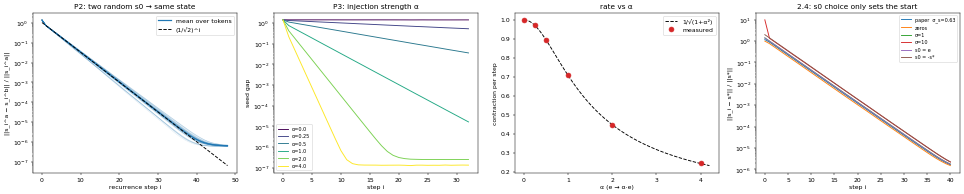

In [ ]:
# ── Checkpoint 2 figures ─────────────────────────────────────────────────
fig, ax = plt.subplots(1, 4, figsize=(22, 4.6))
i_ax = torch.arange(r_max + 1)

# (a) per-token seed gap vs step, with the 1/sqrt(2)^i prediction
for j in range(1, n_tok): ax[0].semilogy(i_ax, gap[:, j].cpu(), color="C0", alpha=0.15, lw=0.8)
ax[0].semilogy(i_ax, gap[:, tk].mean(-1).cpu(), color="C0", lw=2, label="mean over tokens")
ax[0].semilogy(i_ax, 2 ** (-i_ax / 2) * gap[1, tk].mean().item() * 2**0.5, "k--", label="(1/√2)^i")
ax[0].set_xlabel("recurrence step i"); ax[0].set_ylabel("||s_i^a − s_i^b|| / ||s_i^a||")
ax[0].set_title("P2: two random s0 → same state"); ax[0].legend()

# (b) alpha sweep: gap curves
for k, a in enumerate(alphas):
    ax[1].semilogy(range(33), sweep[a], color=plt.cm.viridis(k / (len(alphas) - 1)), label=f"α={a}")
ax[1].set_xlabel("step i"); ax[1].set_ylabel("seed gap"); ax[1].set_title("P3: injection strength α"); ax[1].legend(fontsize=8)

# (c) alpha sweep: measured rate vs 1/sqrt(1+alpha^2)
aa = torch.linspace(0, 4.2, 100)
ax[2].plot(aa, 1 / torch.sqrt(1 + aa**2), "k--", label="1/√(1+α²)")
ax[2].plot(alphas, [fit_rate(sweep[a]) for a in alphas], "o", color="C3", ms=8, label="measured")
ax[2].set_xlabel("α (e → α·e)"); ax[2].set_ylabel("contraction per step"); ax[2].set_title("rate vs α"); ax[2].legend()

# (d) every s0 variant reaches the same s*
for nm, c in dist_curves.items(): ax[3].semilogy(range(41), c, label=nm)
ax[3].set_xlabel("step i"); ax[3].set_ylabel("||s_i − s*|| / ||s*||"); ax[3].set_title("2.4: s0 choice only sets the start"); ax[3].legend(fontsize=8)
plt.tight_layout(); show(fig, "ckpt2_recurrence")

### Checkpoint 2 results (untrained R, paper init, h = 5280, both T4s)

| prediction | predicted | measured |
|---|---|---|
| P1: e's share of adapter power, step 1 | 1/(1+0.6235²) = 0.7201 | **0.7197** |
| P1: same share, steps ≥ 2 | 0.5 | **0.4998 – 0.5016** |
| P2: seed-gap contraction per step | 1/√2 = 0.7071 | **0.7074** (step size 0.7078) |
| P3: α = 0 / 0.25 / 0.5 / 1 / 2 / 4 | 1.000 / .9701 / .8944 / .7071 / .4472 / .2425 | **.9997 / .9708 / .8951 / .7074 / .4476 / .2429** |
| P4: rate is the same for every token | spread ≈ 0 | mean 0.7063, std **0.008** (45 tokens) |

**What this says about R at initialisation.**
- **It is a contraction with a known rate.** At init R(e,s) ≈ rmsnorm(A_s s + A_e e), and every step shrinks the difference between any two states by 1/√2. That number comes from a single ratio: the norm is shared between s and e, and both have RMS 1. It does not depend on h or on σ.
- **Path independence holds at init, before any training.** Six very different s₀ (the paper's σ_s, zeros, σ=1, σ=10, s₀ = e, and s₀ = −s*) all land on the **same** s*, at the same 0.707 rate. They only start at different distances.
- **The answer to the Checkpoint-1 question: the s₀/e scale mismatch only affects step 1.** It changes e's share of the first step from 50% to 72%. After that, n_c fixes RMS(s) = 1 and nothing remembers σ_s. At init, s₀ = 0 even starts *closest* to s* (0.76 vs 0.89 for the paper's σ_s). The paper's σ_s is not special here, so any reason for it has to come from training (the randomness it adds), not from the forward dynamics.
- **Injecting e is what makes it converge.** With α = 0 the rate is 0.9997, and after 32 steps the gap is still 1.41 (= √2, two independent unit-RMS random vectors). This is the paper's footnote 1 ("if e was provided only at the start … not stable") as a measurement. Every bit of contraction comes from e's share of the normalised sum.
- **Practical consequence:** at r̄ = 32 the init state is converged to 1.7e-5, and it hits the fp32 floor near i ≈ 45. So at init, extra iterations beyond ~35 compute nothing new. Whatever "thinking longer" means in the trained model has to be learned, and the next checkpoints can test that.
- **The fixed point** has the same geometry as e (token corr 0.041 vs 0.040, eff. rank 16.0 vs 16.2), but it is *not* e (cos 0.002, i.e. random). Repeated tokens land within 1.5% of each other.
- **Parameter check:** R = 1.637 B (adapter 55.8 M + 4 × 395 M), against the paper's "~1.5B in the core".
- **Compute:** one iteration takes ~140 ms (46 tokens, batch 2, fp32). With a replica of R on the second T4, independent jobs run **1.96×** faster, and the replicas give bit-identical results.

## Checkpoint 3: the Coda **C** and the full model p = C(s_r)

Sec 3.2: *"The coda contains l_C layers, normalization by n_c, and projection into the vocabulary using tied embeddings Eᵀ."* So

  logits = rmsnorm( L₂∘L₁(s_r) ) · Eᵀ  (the same E as the prelude, with no γ on the way out)

The paper reuses the symbol n_c for this final norm. Its weights are 1 at init either way, so I give the coda its own norm module.

**Predictions at init.**
- **Total size:** 0.346 (E) + 0.791 (P) + 1.637 (R) + 0.791 (C) = **3.56 B**, against the paper's "3.5B".
- **Initial loss.** The final hidden state x has RMS 1 and E has σ ≈ 0.0086, so each logit x·E_v has std √h·σ ≈ 0.62. For random-looking logits with std σ_ℓ, the cross-entropy is ≈ ln|V| + σ_ℓ²/2 = 11.090 + 0.195 ≈ **11.28**, not 11.09.
- **Logits vs r.** The state converges at 1/√2 per step, and KL is quadratic in small changes. So **KL(p_i ‖ p_{i−1}) should halve every step**, which means the paper's exit threshold 5·10⁻⁴ would fire after a fixed number of steps even on the untrained model.

Memory plan (fp32): P and R on GPU 0, C on GPU 1 next to the R replica, and the head on GPU 0 where E lives.

In [ ]:
# ── Coda C + tied head, full paper-scale forward pass ────────────────────
class Coda(nn.Module):
    """logits = n_c( L_lC(...L_1(s)) ) @ E^T   (E passed in: tied with the prelude embedding)"""
    def __init__(s, cfg):
        super().__init__(); s.cfg = cfg
        s.layers = nn.ModuleList(SandwichLayer(cfg) for _ in range(cfg.l_C))
        s.n_c = RMSNorm(cfg.h, cfg.norm_eps)
        paper_init_(s, cfg)
    def forward(s, state, cos, sin):
        x = state
        for L in s.layers:
            x = L(x, cos, sin)
        return s.n_c(x)                                   # hidden; head applied by caller (E may live elsewhere)

torch.manual_seed(2)
with torch.device("cuda:1"):
    C = Coda(cfg).eval()
nC = sum(p.numel() for p in C.parameters()); nP = sum(p.numel() for p in P.parameters())
print(f"P {nP/1e9:.3f} B (incl. E {P.E.weight.numel()/1e9:.3f}) + R {nR/1e9:.3f} B + C {nC/1e9:.3f} B "
      f"= {(nP+nR+nC)/1e9:.3f} B total  (paper: 3.5B)")
for d in range(NG): print(f"cuda:{d} allocated {torch.cuda.memory_allocated(d)/2**30:.2f} GiB")

@torch.no_grad()
def full_forward(ids, r, seed=0, keep_every_step=False):
    """p = C(s_r). If keep_every_step, also return logits after every iteration i=1..r (coda+head applied to s_i)."""
    cos0, sin0 = rope_tables(cfg, ids.shape[1], "cuda:0"); cos1, sin1 = cos0.to("cuda:1"), sin0.to("cuda:1")
    e = P(ids)
    s = sample_s0(e.shape, seed=seed)
    head = lambda st: C(st.to("cuda:1"), cos1, sin1).to("cuda:0") @ P.E.weight.T
    per_step = []
    for i in range(r):
        s = R(e, s, cos0, sin0)
        if keep_every_step: per_step.append(head(s).float().log_softmax(-1).cpu())
    return head(s), per_step

ids_c = encode(para)
t0 = time.time(); logits, steps = full_forward(ids_c, r=32, keep_every_step=True); torch.cuda.synchronize()
print(f"\nfull forward r=32 ({ids_c.shape[1]} tokens) with coda at every step: {time.time()-t0:.1f}s")
ce = F.cross_entropy(logits[0, :-1].float(), ids_c[0, 1:])
print(f"initial next-token loss: {ce.item():.4f}   predicted ≈ ln V + σ_ℓ²/2 = {math.log(cfg.vocab):.3f} + "
      f"{(logits.float().std().item())**2/2:.3f} (measured logit std {logits.float().std().item():.4f})")

kl = [F.kl_div(steps[i-1], steps[i], log_target=True, reduction="none").sum(-1)[0, 1:].mean().item()
      for i in range(1, len(steps))]          # KL(p_i || p_{i-1}), mean over tokens
print("\nKL(p_i || p_{i-1}) at i = 2,4,8,12,16,24:", " ".join(f"{kl[i-2]:.1e}" for i in (2, 4, 8, 12, 16, 24)))
print(f"fitted per-step ratio: {fit_rate(torch.tensor(kl), lo=1, floor=1e-12):.4f}   (predicted 0.5)")
exit_step = next((i for i in range(2, len(steps)+1) if kl[i-2] < 5e-4), None)
print(f"paper's exit rule KL < 5e-4 would fire at step {exit_step} on the UNTRAINED model")

P 1.137 B (incl. E 0.346) + R 1.637 B + C 0.791 B = 3.565 B total  (paper: 3.5B)
cuda:0 allocated 10.46 GiB
cuda:1 allocated 9.06 GiB

full forward r=32 (46 tokens) with coda at every step: 4.5s
initial next-token loss: 11.2419   predicted ≈ ln V + σ_ℓ²/2 = 11.090 + 0.195 (measured logit std 0.6243)

KL(p_i || p_{i-1}) at i = 2,4,8,12,16,24: 1.6e-01 3.9e-02 2.4e-03 1.5e-04 9.8e-06 7.5e-08
fitted per-step ratio: 0.5607   (predicted 0.5)
paper's exit rule KL < 5e-4 would fire at step 11 on the UNTRAINED model


### Checkpoint 3 results (full 3.5B model, untrained)
- **Size: 3.565 B** = P 1.137 B (including E 0.346 B) + R 1.637 B + C 0.791 B. Paper: "3.5B".
- **Initial loss 11.24**, against the ≈ 11.28 prediction (ln V = 11.09 plus the logit-spread term 0.19). With 45 targets the measurement has a noise of about ±0.09, so it agrees. The logit std is 0.6243, the √h·σ_E predicted.
- **KL(p_i‖p_{i−1}) halves each step:** 0.16 → 3.9e-2 (i=4) → 2.4e-3 (8) → 1.5e-4 (12) → 9.8e-6 (16). Between i=4 and 16 the per-step ratio is 0.50, the square of the 0.707 state contraction. The overall fit (0.56) is pulled up by the fp32 floor at the tail.
- **The paper's exit rule (KL < 5·10⁻⁴) fires at step 11 on a model that has never been trained.** So a KL exit on its own does not show "thinking". The trained model has to exit at *different* steps for easy and hard tokens, and that is tested in Checkpoint 6.

---
## From here on: small scale, trained
Training even one step of the 3.5B model is out of reach on two T4s. Everything below uses **the same architecture code at small scale**, in `rd.py`, which is written out below so it can run as a background training process on each GPU.

| | paper main | paper small | here |
|---|---|---|---|
| shape (l_P, l_R, l_C) | (2,4,2) | (1,4,1) | **(1,2,1)** |
| h, heads | 5280, 55 | 1024 | **256, 4×64** |
| MLP inner | 17920 (3.39 h) | | **864 (3.39 h)** |
| r̄ train, k (truncated BPTT) | 32, 8 | | **16, 8** |
| r sampler | log-normal Poisson, σ = ½ | | same |
| init, norms, adapter, tied head | Sec 4.1 | | same |
| optimiser | Adam β=(0.9,0.95), warm-up + constant LR, clip 1 | | same (AdamW, lr 1e-3, fp16 autocast) |

**Task (final version, v5): interleaved variable chains.** Each statement is `N=O+d;`, where `O` is a digit (a chain's root) or the previous variable of the same chain, and d ∈ {0,1} (mod 10). The 12 variables form 2–4 independent chains of random length, and their statements are **interleaved at random**. After `?`, every variable is queried with its value right after its name: `^y=0+0;n=3+1;m=y+1;…?d3m1c4…$`.
- A query's **depth** is its position in its chain (1–11), which is the number of dependent look-ups needed.
- A causal transformer can only move information from one position to a later one through one more layer, so depth d needs about d layer-hops. The paper's non-recurrent twin, 4 layers, should therefore fail on deep queries.
- The loss is next-token CE on the value digits only. The rest of the text is random by construction, and chance is 0.104.

It took four task versions to get something that is both learnable in budget and not shortcut-able. The history is kept in the cells below: v1–v3 used `+ − *` with d ∈ 0..9, which could not be learned in budget. v4 had one dominant chain, which allowed a counting shortcut that a 4-layer model could compute.

In [ ]:
# ── free the paper-scale models (Checkpoints 1-3 are done; re-run those cells to rebuild) ──
for name in ["P", "R", "R1", "C", "R_on", "S", "esh", "e2", "s0", "logits", "steps", "e", "rec", "e_p", "rec_p",
             "ref", "res", "curves", "job", "variants", "s_ref", "s_star", "dist_curves", "sweep"]:
    globals().pop(name, None)
for k in ("last_traceback", "last_value", "last_type", "last_exc"):
    if hasattr(sys, k): setattr(sys, k, None)
gc.collect()
# the OOM'd deepcopy's dead frame still references the old R: release any large GPU parameter storage left
for o in gc.get_objects():
    try:
        if isinstance(o, nn.Parameter) and o.is_cuda and o.numel() > 1_000_000: o.data = torch.empty(0)
    except Exception: pass
gc.collect(); torch.cuda.empty_cache()
for d in range(NG): print(f"cuda:{d} allocated {torch.cuda.memory_allocated(d)/2**30:.2f} GiB, free {torch.cuda.mem_get_info(d)[0]/2**30:.1f} GiB")

cuda:0 allocated 0.11 GiB, free 13.0 GiB
cuda:1 allocated 0.01 GiB, free 14.4 GiB


In [ ]:
%%writefile /content/rd.py
# rd.py - small-scale Recurrent-Depth LM (arXiv 2502.05171), same architecture as the notebook's
# Checkpoint 1-3 cells, plus: KV-cache inference, the training objective, and a multi-hop program task.
import math, random, time, json, os, argparse
import torch, torch.nn as nn, torch.nn.functional as F
from dataclasses import dataclass, asdict


# ═════════════════════════════════════ config ═════════════════════════════════════
@dataclass
class Cfg:
    vocab: int = 48
    h: int = 256
    n_heads: int = 4
    mlp_inner: int = 864          # 17920/5280 = 3.39 x h, as in the paper
    l_P: int = 1
    l_R: int = 2
    l_C: int = 1
    r_bar: int = 16               # mean recurrence (training); sets init depth l
    rope_base: float = 50000.0
    norm_eps: float = 1e-6
    max_seq: int = 512
    @property
    def head_dim(self): return self.h // self.n_heads
    @property
    def l_eff(self): return self.l_P + self.r_bar * self.l_R + self.l_C
    @property
    def std_in(self): return math.sqrt(2 / (5 * self.h))
    @property
    def std_out(self): return math.sqrt(1 / (5 * self.h * self.l_eff))
    @property
    def emb_scale(self): return math.sqrt(self.h)
    @property
    def std_s(self): return math.sqrt(2 / 5)


# ═════════════════════════════════════ layers ═════════════════════════════════════
def tnormal_(w, std, gen=None):
    return nn.init.trunc_normal_(w, 0.0, std, -3 * std, 3 * std, generator=gen)

class RMSNorm(nn.Module):
    def __init__(s, d, eps):
        super().__init__(); s.eps = eps; s.weight = nn.Parameter(torch.ones(d))
    def forward(s, x):
        xf = x.float()
        return (xf * torch.rsqrt(xf.pow(2).mean(-1, keepdim=True) + s.eps)).to(x.dtype) * s.weight.to(x.dtype)

def apply_rope(x, cos, sin):                 # x (B,H,T,d); cos/sin (T, d/2)
    x1, x2 = x[..., ::2], x[..., 1::2]
    c, s = cos.to(x.dtype), sin.to(x.dtype)
    return torch.stack((x1 * c - x2 * s, x1 * s + x2 * c), -1).flatten(-2)

class KVSlot:
    """Preallocated K/V for one attention layer (one recurrence slot for core layers)."""
    def __init__(s, B, H, T, d, device, dtype):
        s.K = torch.zeros(B, H, T, d, device=device, dtype=dtype)
        s.V = torch.zeros(B, H, T, d, device=device, dtype=dtype)

class Attention(nn.Module):
    def __init__(s, cfg):
        super().__init__(); s.cfg = cfg; h = cfg.h
        s.q = nn.Linear(h, h, bias=True); s.k = nn.Linear(h, h, bias=True)     # bias on q,k only
        s.v = nn.Linear(h, h, bias=False); s.o = nn.Linear(h, h, bias=False)
    def forward(s, x, cos, sin, slot=None, p0=0):
        B, T, h = x.shape; H, d = s.cfg.n_heads, s.cfg.head_dim
        q, k, v = (m(x).view(B, T, H, d).transpose(1, 2) for m in (s.q, s.k, s.v))
        q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)
        if slot is None:
            y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        else:                                  # write this chunk at [p0, p0+T), attend to [0, p0+T)
            slot.K[:, :, p0:p0 + T] = k.to(slot.K.dtype); slot.V[:, :, p0:p0 + T] = v.to(slot.V.dtype)
            K, V = slot.K[:, :, :p0 + T].to(q.dtype), slot.V[:, :, :p0 + T].to(q.dtype)
            mask = None
            if T > 1:
                mask = torch.arange(p0 + T, device=x.device)[None, :] <= (p0 + torch.arange(T, device=x.device))[:, None]
            y = F.scaled_dot_product_attention(q, K, V, attn_mask=mask)
        return s.o(y.transpose(1, 2).reshape(B, T, h))

class GatedMLP(nn.Module):
    def __init__(s, cfg):
        super().__init__()
        s.gate = nn.Linear(cfg.h, cfg.mlp_inner, bias=False); s.up = nn.Linear(cfg.h, cfg.mlp_inner, bias=False)
        s.down = nn.Linear(cfg.mlp_inner, cfg.h, bias=False)
    def forward(s, x): return s.down(F.silu(s.gate(x)) * s.up(x))

class SandwichLayer(nn.Module):
    """x_hat = n2(x + Attn(n1(x)));  x_out = n4(x_hat + MLP(n3(x_hat)))"""
    def __init__(s, cfg):
        super().__init__()
        s.n1, s.n2, s.n3, s.n4 = (RMSNorm(cfg.h, cfg.norm_eps) for _ in range(4))
        s.attn, s.mlp = Attention(cfg), GatedMLP(cfg)
    def forward(s, x, cos, sin, slot=None, p0=0):
        x_hat = s.n2(x + s.attn(s.n1(x), cos, sin, slot, p0))
        return s.n4(x_hat + s.mlp(s.n3(x_hat)))


# ═════════════════════════════════════ model ═════════════════════════════════════
class Cache:
    """KV cache. Keys: ('P',l), ('C',l), ('R',l,it). With budget b, core slot it -> it % b (Sec 6.2)."""
    def __init__(s, model, B, T, device, dtype=torch.float32, budget=None):
        s.cfg = model.cfg; s.B, s.T, s.device, s.dtype, s.budget = B, T, device, dtype, budget; s.slots = {}
    def key(s, k):
        return ("R", k[1], k[2] % s.budget) if (k[0] == "R" and s.budget) else k
    def slot(s, k):
        k = s.key(k)
        if k not in s.slots:
            s.slots[k] = KVSlot(s.B, s.cfg.n_heads, s.T, s.cfg.head_dim, s.device, s.dtype)
        return s.slots[k]
    def copy_core(s, it_from, it_to, pos, rows):
        """For batch rows `rows` (bool), copy core K/V at positions `pos` from iteration it_from to it_to
        ('attend to the last, deepest available KV state', Remark 6.1)."""
        for l in range(s.cfg.l_R):
            a, b = s.slot(("R", l, it_from)), s.slot(("R", l, it_to))
            if a is b: continue
            b.K[rows, :, pos] = a.K[rows, :, pos]; b.V[rows, :, pos] = a.V[rows, :, pos]

class RecurrentDepthLM(nn.Module):
    def __init__(s, cfg, seed=0):
        super().__init__(); s.cfg = cfg; h = cfg.h
        s.E = nn.Embedding(cfg.vocab, h)
        s.prelude = nn.ModuleList(SandwichLayer(cfg) for _ in range(cfg.l_P))
        s.A = nn.Linear(2 * h, h, bias=False)                                 # adapter [s; e] -> h
        s.core = nn.ModuleList(SandwichLayer(cfg) for _ in range(cfg.l_R))
        s.n_R = RMSNorm(h, cfg.norm_eps)                                      # n_c of the core
        s.coda = nn.ModuleList(SandwichLayer(cfg) for _ in range(cfg.l_C))
        s.n_C = RMSNorm(h, cfg.norm_eps)                                      # final norm before tied head
        inv = 1.0 / (cfg.rope_base ** (torch.arange(0, cfg.head_dim, 2).float() / cfg.head_dim))
        ang = torch.outer(torch.arange(cfg.max_seq).float(), inv)
        s.register_buffer("cos", ang.cos(), persistent=False); s.register_buffer("sin", ang.sin(), persistent=False)
        s.reset_parameters(seed)

    @torch.no_grad()
    def reset_parameters(s, seed=0):
        g = torch.Generator().manual_seed(seed)
        for name, p in s.named_parameters():
            if p.dim() == 1:
                p.fill_(1.0) if name.endswith("weight") else p.zero_()
            else:
                w = torch.empty(p.shape)
                tnormal_(w, s.cfg.std_out if name.endswith(("attn.o.weight", "mlp.down.weight")) else s.cfg.std_in, g)
                p.copy_(w)

    def tables(s, p0, T): return s.cos[p0:p0 + T], s.sin[p0:p0 + T]

    def embed(s, ids, p0=0, cache=None):                                       # e = P(x)
        cos, sin = s.tables(p0, ids.shape[1])
        x = s.E(ids) * s.cfg.emb_scale
        for l, L in enumerate(s.prelude):
            x = L(x, cos, sin, cache.slot(("P", l)) if cache else None, p0)
        return x

    def core_step(s, e, st, p0=0, cache=None, it=0):                          # s_i = R(e, s_{i-1})
        cos, sin = s.tables(p0, e.shape[1])
        x = s.A(torch.cat([st.to(e.dtype), e], -1))
        for l, L in enumerate(s.core):
            x = L(x, cos, sin, cache.slot(("R", l, it)) if cache else None, p0)
        return s.n_R(x)

    def decode(s, st, p0=0, cache=None, return_hidden=False):               # p = C(s)
        cos, sin = s.tables(p0, st.shape[1])
        x = st
        for l, L in enumerate(s.coda):
            x = L(x, cos, sin, cache.slot(("C", l)) if cache else None, p0)
        x = s.n_C(x)
        logits = x @ s.E.weight.T.to(x.dtype)
        return (logits, x) if return_hidden else logits

    def init_state(s, shape, device, gen=None, kind="random"):
        if kind == "zeros": return torch.zeros(shape, device=device)
        w = torch.empty(shape, device=device)
        return tnormal_(w, s.cfg.std_s, gen)

    def forward(s, ids, r, k=None, s0=None, gen=None, return_states=False):
        """Full-sequence forward. r iterations; if k is given, gradients flow only through the last k
        (truncated backprop, Sec 3.3). return_states -> list [s_0..s_r] (detached)."""
        e = s.embed(ids)
        st = s.init_state(e.shape, e.device, gen) if s0 is None else s0
        states = [st.detach()] if return_states else None
        n_free = 0 if k is None else max(0, r - k)
        with torch.no_grad():
            for i in range(n_free):
                st = s.core_step(e, st)
                if return_states: states.append(st.detach())
        if n_free:
            # autocast caches the fp16 weight casts it made under no_grad; those copies have no grad_fn, and
            # reusing them would silently cut every core weight out of the gradient. Drop the cache.
            torch.clear_autocast_cache()
        for i in range(n_free, r):
            st = s.core_step(e, st)
            if return_states: states.append(st.detach())
        logits = s.decode(st)
        return (logits, states) if return_states else logits


# ═══════════════════════ training objective: r ~ log-normal Poisson ═══════════════════════
def sample_r(r_bar, sigma=0.5, rng=None):
    """Eq. (1)-(2): tau ~ N(log r_bar - sigma^2/2, sigma),  r ~ Poisson(e^tau) + 1.  E[r] = r_bar + 1."""
    rng = rng or random
    tau = rng.gauss(math.log(r_bar) - 0.5 * sigma ** 2, sigma)
    lam = math.exp(tau)
    # Poisson sample by inversion (exact, lam is O(10-100))
    u, k, p = rng.random(), 0, math.exp(-lam)
    c = p
    while u > c and k < 10000:
        k += 1; p *= lam / k; c += p
    return k + 1


# ═══════════════════════ task: multi-hop programs (depth = # dependent ops) ═══════════════════════
LETTERS = "abcdefghijklmnopqrstuvwxyz"
SYMS = list(LETTERS) + list("0123456789") + list("+-*=;?") + ["^", "$"]      # ^ BOS, $ EOS
STOI = {c: i for i, c in enumerate(SYMS)}
BOS, EOS = STOI["^"], STOI["$"]
OPS = {"+": lambda a, b: (a + b) % 10, "-": lambda a, b: (a - b) % 10, "*": lambda a, b: (a * b) % 10}

def make_program(n_vars, n_q, rng, beta=1.5, p_root=0.08):
    """Statements 'N=O?d;' (5 chars + ';'): O is a digit (root) or an earlier variable. Parents favour deep
    variables (softmax(beta*depth)) so chains are long but not adjacent. Returns text, answers, depths."""
    names = rng.sample(LETTERS, n_vars)
    val, dep, stmts = {}, {}, []
    for j, nm in enumerate(names):
        op, d = rng.choice("+-*"), rng.randrange(10)
        if j == 0 or rng.random() < p_root:
            a = rng.randrange(10); src = str(a); val[nm] = OPS[op](a, d); dep[nm] = 1
        else:
            prev = names[:j]; w = [math.exp(beta * dep[p]) for p in prev]
            par = rng.choices(prev, weights=w)[0]
            src = par; val[nm] = OPS[op](val[par], d); dep[nm] = dep[par] + 1
        stmts.append(f"{nm}={src}{op}{d};")
    qs = rng.sample(names, n_q)
    text = "".join(stmts) + "?" + "".join(q + str(val[q]) for q in qs) + "$"      # '?k3q7a1$': value right after its name
    return text, [val[q] for q in qs], [dep[q] for q in qs]

def make_batch(B, n_vars, n_q, rng, device="cpu"):
    rows, depths = [], []
    for _ in range(B):
        t, a, d = make_program(n_vars, n_q, rng)
        rows.append([BOS] + [STOI[c] for c in t]); depths.append(d)
    ids = torch.tensor(rows, device=device)
    L = ids.shape[1]; ans_pos = torch.arange(L - 2 * n_q, L - 1, 2, device=device)  # the n_q value digits
    return ids, ans_pos, torch.tensor(depths, device=device)

def answer_loss_acc(logits, ids, ans_pos):
    """Next-token CE restricted to the answer digits (predicted from the token before each)."""
    lg = logits[:, ans_pos - 1].float(); tg = ids[:, ans_pos]
    loss = F.cross_entropy(lg.reshape(-1, lg.shape[-1]), tg.reshape(-1))
    return loss, (lg.argmax(-1) == tg)

def hidden_corr(st):
    """Mean cosine between different positions of the latent state (Fig 5 collapse metric), BOS excluded."""
    x = F.normalize(st[:, 1:].float(), dim=-1); n = x.shape[1]
    c = x @ x.transpose(1, 2)
    return ((c.sum((1, 2)) - n) / (n * (n - 1))).mean().item()


# ═══════════════════════ inference: cached generation + Sec 6 features ═══════════════════════
@torch.no_grad()
def generate(model, prompt, n_new, r, exit_kl=None, budget=None, warm_start=False, s0_kind="random",
             seed=0, return_logits=False, force=None):
    """Greedy decoding with a per-iteration KV cache.
    prompt[:, :-1] is prefilled with r iterations; then n_new tokens are decoded, starting from prompt[:, -1].
    exit_kl  : per-token early exit when KL(p_i || p_{i-1}) < exit_kl (Sec 6.1); exited tokens expose their
               last KV to later iterations (Remark 6.1).
    budget   : recurrent KV-cache budget, slot = i mod budget (Sec 6.2).
    warm_start: s0 of each new token = final state of the previous token (Sec 6.3, continuous CoT).
    force    : optional (B, n_new) ids; entries >= 0 are emitted instead of the model's choice (teacher-forced
               query names), entries < 0 are free.
    Returns tokens (B,n_new), steps used (B,n_new) [, logits (B,n_new,V)]."""
    dev = prompt.device; B, n = prompt.shape
    cache = Cache(model, B, n + n_new, dev, budget=budget)
    g = torch.Generator(device=dev).manual_seed(seed)
    e = model.embed(prompt[:, :-1], 0, cache)
    st = model.init_state(e.shape, dev, g, s0_kind)
    for i in range(r):
        st = model.core_step(e, st, 0, cache, i)
    model.decode(st, 0, cache)
    prev = st[:, -1:]
    tok = prompt[:, -1:]; toks, steps, logs = [], [], []
    for t in range(n_new):
        p0 = n - 1 + t
        e = model.embed(tok, p0, cache)
        st = prev.clone() if warm_start else model.init_state(e.shape, dev, g, s0_kind)
        active = torch.ones(B, dtype=torch.bool, device=dev)
        used = torch.full((B,), r, device=dev)
        lp_prev = None
        for i in range(r):
            new = model.core_step(e, st, p0, cache, i)
            st = torch.where(active[:, None, None], new, st)
            if i > 0 and not active.all():
                cache.copy_core(i - 1, i, p0, ~active)
            if exit_kl is not None:
                lp = model.decode(st, p0, cache).float().log_softmax(-1)[:, 0]
                if lp_prev is not None:
                    kl = (lp.exp() * (lp - lp_prev)).sum(-1)
                    newly = active & (kl < exit_kl)
                    used[newly] = i + 1; active = active & ~newly
                lp_prev = lp
                if not active.any():
                    for j in range(i + 1, r):
                        cache.copy_core(j - 1, j, p0, torch.ones(B, dtype=torch.bool, device=dev))
                    break
        logits = model.decode(st, p0, cache)[:, 0]
        tok = logits.argmax(-1, keepdim=True)
        if force is not None:
            tok = torch.where(force[:, t:t + 1] >= 0, force[:, t:t + 1], tok)
        toks.append(tok); steps.append(used); logs.append(logits); prev = st
    out = (torch.cat(toks, 1), torch.stack(steps, 1))
    return out + (torch.stack(logs, 1),) if return_logits else out

@torch.no_grad()
def speculative_one(model, prompt, n_new, r_draft, r_verify, seed=0, force=None):
    """Self-speculative decoding (Sec 6.4) for one sequence: draft the remaining tokens with r_draft,
    verify all of them in one parallel pass at r_verify, keep the agreeing prefix + the verifier's next token.
    Returns tokens (1,n_new), sequential core iterations used, drafted, accepted."""
    ctx = prompt; done = 0; cost = 0; drafted = 0; accepted = 0; rnd = 0
    while done < n_new:
        m = n_new - done
        fz = None if force is None else force[:, done:]
        d, _ = generate(model, ctx, m, r_draft, seed=seed + rnd, force=fz)
        ver = model(torch.cat([ctx, d[:, :-1]], 1), r_verify,
                    gen=torch.Generator(device=ctx.device).manual_seed(seed + 1000 + rnd))[:, ctx.shape[1] - 1:].argmax(-1)
        if fz is not None: ver = torch.where(fz >= 0, fz, ver)
        cost += m * r_draft + r_verify; drafted += m
        agree = (ver[0] == d[0]).long()
        a = int(agree.cumprod(0).sum().item())
        take = min(a + 1, m); accepted += min(a, m)
        ctx = torch.cat([ctx, ver[:, :take]], 1); done += take; rnd += 1
    return ctx[:, prompt.shape[1]:], cost, drafted, accepted


# ═════════════════════════════════════ training ═════════════════════════════════════
def train(out, gpu=0, steps=6000, bs=128, lr=5e-4, r_bar=16, k=8, fixed_r=None, n_vars=12, n_q=0,
          seed=0, eval_every=250, warmup=300, cfg_over=None, n_vars_min=None):
    """n_q=0 -> query every variable. n_vars_min -> each batch draws its program size from [n_vars_min, n_vars]."""
    torch.manual_seed(seed); rng = random.Random(seed)
    dev = f"cuda:{gpu}" if torch.cuda.is_available() else "cpu"
    cfg = Cfg(r_bar=r_bar, **(cfg_over or {}))
    model = RecurrentDepthLM(cfg, seed=seed).to(dev)
    decay = [p for n_, p in model.named_parameters() if p.dim() >= 2]
    no_decay = [p for n_, p in model.named_parameters() if p.dim() < 2]
    opt = torch.optim.AdamW([{"params": decay, "weight_decay": 0.1}, {"params": no_decay, "weight_decay": 0.0}],
                            lr=lr, betas=(0.9, 0.95), eps=1e-8)
    sched = torch.optim.lr_scheduler.LambdaLR(opt, lambda t: min(1.0, (t + 1) / warmup))   # warmup, then constant
    use_amp = dev.startswith("cuda")
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
    vrng = random.Random(12345)
    val = make_batch(512, n_vars, n_q or n_vars, vrng, dev)
    os.makedirs(out, exist_ok=True)
    json.dump({"cfg": asdict(cfg), "args": dict(steps=steps, bs=bs, lr=lr, r_bar=r_bar, k=k, fixed_r=fixed_r,
               n_vars=n_vars, n_q=n_q, seed=seed, n_vars_min=n_vars_min)}, open(f"{out}/config.json", "w"))
    log = open(f"{out}/log.jsonl", "a"); t0 = time.time(); run_loss = None

    def evaluate(step):
        model.eval(); rec = {"step": step, "time": time.time() - t0}
        ids, ap, dp = val
        g = torch.Generator(device=dev).manual_seed(0)
        for r in ([1] if fixed_r == 1 else [1, 2, 4, 8, 16, 32]):
            with torch.no_grad(), torch.autocast("cuda", torch.float16, enabled=use_amp):
                lg, states = model(ids, r, gen=g, return_states=True)
            loss, ok = answer_loss_acc(lg, ids, ap)
            rec[f"acc_r{r}"] = ok.float().mean().item(); rec[f"loss_r{r}"] = loss.item()
            rec[f"corr_r{r}"] = hidden_corr(states[-1])
        rec["train_loss"] = run_loss
        log.write(json.dumps(rec) + "\n"); log.flush(); model.train()
        print(json.dumps({k_: (round(v, 4) if isinstance(v, float) else v) for k_, v in rec.items()}), flush=True)

    model.train()
    for step in range(steps + 1):
        if step % eval_every == 0: evaluate(step)
        if step == steps: break
        nv = rng.randint(n_vars_min or n_vars, n_vars)
        ids, ap, _ = make_batch(bs, nv, n_q or nv, rng, dev)
        r = fixed_r if fixed_r else sample_r(r_bar, rng=rng)
        with torch.autocast("cuda", torch.float16, enabled=use_amp):
            lg = model(ids, r, k=k)
            loss, _ = answer_loss_acc(lg, ids, ap)
        opt.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(opt); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(opt); scaler.update(); sched.step()
        run_loss = loss.item() if run_loss is None else 0.98 * run_loss + 0.02 * loss.item()
        if (step + 1) % 1000 == 0:
            torch.save({"cfg": asdict(cfg), "model": model.state_dict(), "step": step + 1}, f"{out}/ckpt.pt")
    torch.save({"cfg": asdict(cfg), "model": model.state_dict(), "step": steps}, f"{out}/ckpt.pt")
    open(f"{out}/DONE", "w").write("ok")

def load(path, device):
    ck = torch.load(path, map_location=device)
    m = RecurrentDepthLM(Cfg(**ck["cfg"])).to(device); m.load_state_dict(ck["model"]); m.eval()
    return m


if __name__ == "__main__":
    ap = argparse.ArgumentParser()
    ap.add_argument("--out", required=True); ap.add_argument("--gpu", type=int, default=0)
    ap.add_argument("--steps", type=int, default=6000); ap.add_argument("--bs", type=int, default=128)
    ap.add_argument("--lr", type=float, default=5e-4); ap.add_argument("--r_bar", type=int, default=16)
    ap.add_argument("--k", type=int, default=8); ap.add_argument("--fixed_r", type=int, default=None)
    ap.add_argument("--n_vars", type=int, default=12); ap.add_argument("--n_q", type=int, default=0)
    ap.add_argument("--seed", type=int, default=0); ap.add_argument("--eval_every", type=int, default=250)
    ap.add_argument("--n_vars_min", type=int, default=None)
    a = ap.parse_args()
    train(a.out, a.gpu, a.steps, a.bs, a.lr, a.r_bar, a.k, a.fixed_r, a.n_vars, a.n_q, a.seed, a.eval_every,
          n_vars_min=a.n_vars_min)

Overwriting /content/rd.py


In [ ]:
# ── verify rd.py is byte-identical to the locally tested file (md5 of the text, trailing newline normalised) ──
import hashlib, importlib, sys
sys.path.insert(0, "/content")
src = open("/content/rd.py", "rb").read().rstrip(b"\n") + b"\n"
print("md5", hashlib.md5(src).hexdigest(), "| expected b1f94cdec4677cdf8a0c27dba252dd94 | bytes", len(src))
if "rd" in sys.modules: del sys.modules["rd"]
import rd
print("rd imported; vocab symbols:", len(rd.SYMS))

md5 b1f94cdec4677cdf8a0c27dba252dd94 | expected b1f94cdec4677cdf8a0c27dba252dd94 | bytes 21160
rd imported; vocab symbols: 44


In [ ]:
# ── Task v4 patch (applied on top of the rd.py written above; see the probe cells further down for why) ──
# v1-v3 used ops '+-*' with d in 0..9: a 3-op x 10 x 10 lookup table the 4-layer net could not learn in budget
# (probe, r=1, 2-variable programs, 800 steps: mixed ops 34%, '+' only 12% ~ chance, copy 91%, '+0/+1' 85%).
# v4: every statement is 'N=O+d;' with d in {0,1}; a value = root + (#'+1' hops on its chain) mod 10.
s = open("/content/rd.py", encoding="utf-8").read().rstrip("\n") + "\n"
a = '''def make_program(n_vars, n_q, rng, beta=1.5, p_root=0.08):
    """Statements 'N=O?d;' (5 chars + ';'): O is a digit (root) or an earlier variable. Parents favour deep
    variables (softmax(beta*depth)) so chains are long but not adjacent. Returns text, answers, depths."""
    names = rng.sample(LETTERS, n_vars)
    val, dep, stmts = {}, {}, []
    for j, nm in enumerate(names):
        op, d = rng.choice("+-*"), rng.randrange(10)'''
b = '''def make_program(n_vars, n_q, rng, beta=1.5, p_root=0.08, ops="+", d_max=2):
    """Statements 'N=O+d;' (5 chars + ';'): O is a digit (root) or an earlier variable, d in {0,1}, mod 10.
    Parents favour deep variables (softmax(beta*depth)) so chains are long but not adjacent.
    Task v4: ops/d_max were '+-*'/10 in v1-v3, which a 4-layer net could not learn in budget (probes in notebook).
    Returns text, answers, depths."""
    names = rng.sample(LETTERS, n_vars)
    val, dep, stmts = {}, {}, []
    for j, nm in enumerate(names):
        op, d = rng.choice(ops), rng.randrange(d_max)'''
if s.count(b) == 0:
    assert s.count(a) == 1; s = s.replace(a, b); open("/content/rd.py", "w", encoding="utf-8").write(s)
print("rd.py md5", hashlib.md5(s.encode()).hexdigest(), "| expected 2f9cf3f42434bb822a3421b1f13948ba")
if "rd" in sys.modules: del sys.modules["rd"]
import rd
print(rd.make_program(6, 6, random.Random(3)))

rd.py md5 2f9cf3f42434bb822a3421b1f13948ba | expected 2f9cf3f42434bb822a3421b1f13948ba
('h=9+0;s=h+1;r=s+1;e=r+0;l=e+0;t=l+1;?r1e1l1t2s0h9$', [1, 1, 1, 2, 0, 9], [3, 4, 5, 6, 2, 1])


In [ ]:
# ── Task v5 patch: interleaved independent chains (see the twin's per-depth result further down for why) ──
# v4 grew one dominant chain (parents favoured the deepest variable), so a variable's chain was ~ the whole prefix and
# 'first root + #(+1) seen so far' was an O(1)-layer shortcut: the r=1 twin scored 0.46 at depth 12 (chance 0.10).
s = open("/content/rd.py", encoding="utf-8").read().rstrip("\n") + "\n"
new_mp = '''def make_program(n_vars, n_q, rng, chains=(2, 4), d_max=2):
    """Task v5. Statements 'N=O+d;' (5 chars + ';'), d in {0,1}, values mod 10. The variables form 2-4 independent
    chains of random lengths whose statements are interleaved at random (each chain keeps its order): a chain
    starts with a digit root and every later link is 'previous link + d'. Depth = position in its chain.
    (v4 grew one dominant chain, so a variable's chain was ~ the whole prefix and 'root + #(+1) so far' was an
    O(1)-layer shortcut: the r=1 twin scored 46% at depth 12. Interleaving breaks that.) -> text, answers, depths"""
    names = rng.sample(LETTERS, n_vars)
    c = min(rng.randint(*chains), n_vars)
    cuts = sorted(rng.sample(range(1, n_vars), c - 1))
    lens = [b - a for a, b in zip([0] + cuts, cuts + [n_vars])]
    order = [ci for ci, l in enumerate(lens) for _ in range(l)]; rng.shuffle(order)
    last = [None] * c; val, dep, stmts = {}, {}, []
    for j, ci in enumerate(order):
        nm, d = names[j], rng.randrange(d_max)
        if last[ci] is None:
            a = rng.randrange(10); src = str(a); val[nm] = (a + d) % 10; dep[nm] = 1
        else:
            par = last[ci]; src = par; val[nm] = (val[par] + d) % 10; dep[nm] = dep[par] + 1
        last[ci] = nm; stmts.append(f"{nm}={src}+{d};")
    qs = rng.sample(names, n_q)
    text = "".join(stmts) + "?" + "".join(q + str(val[q]) for q in qs) + "$"      # '?k3q7a1$': value right after its name
    return text, [val[q] for q in qs], [dep[q] for q in qs]

'''
i0, i1 = s.index("def make_program("), s.index("def make_batch(")
s = s[:i0] + new_mp + s[i1:]
open("/content/rd.py", "w", encoding="utf-8").write(s)
print("rd.py md5", hashlib.md5(s.encode()).hexdigest(), "| expected 67cd37db78bcd7d21965961a14eff70d")
if "rd" in sys.modules: del sys.modules["rd"]
import rd
print(rd.make_program(8, 8, random.Random(4)))

rd.py md5 67cd37db78bcd7d21965961a14eff70d | expected 67cd37db78bcd7d21965961a14eff70d
('h=4+0;j=0+0;d=j+1;m=h+1;p=m+0;e=p+0;c=d+1;t=c+1;?e5h4p5d1m5t3c2j0$', [5, 4, 5, 1, 5, 3, 2, 0], [4, 1, 3, 2, 2, 4, 3, 1])


In [ ]:
# ── small patch: --init <ckpt> to continue training from a checkpoint (model weights only) ──
s = open("/content/rd.py", encoding="utf-8").read().rstrip("\n") + "\n"
reps = [
("          seed=0, eval_every=250, warmup=300, cfg_over=None, n_vars_min=None):",
 "          seed=0, eval_every=250, warmup=300, cfg_over=None, n_vars_min=None, init=None):"),
("    model = RecurrentDepthLM(cfg, seed=seed).to(dev)\n",
 "    model = RecurrentDepthLM(cfg, seed=seed).to(dev)\n    if init: model.load_state_dict(torch.load(init, map_location=dev)[\"model\"])      # continue from a checkpoint\n"),
("    ap.add_argument(\"--n_vars_min\", type=int, default=None)\n",
 "    ap.add_argument(\"--n_vars_min\", type=int, default=None); ap.add_argument(\"--init\", default=None)\n"),
("          n_vars_min=a.n_vars_min)", "          n_vars_min=a.n_vars_min, init=a.init)"),
]
if "init=None):" not in s:
    for a, b in reps:
        assert s.count(a) == 1, a[:50]; s = s.replace(a, b)
    open("/content/rd.py", "w", encoding="utf-8").write(s)
print("rd.py md5", hashlib.md5(s.encode()).hexdigest(), "| expected 00f540899b78b9f1640b8544909caabf")
if "rd" in sys.modules: del sys.modules["rd"]
import rd

rd.py md5 00f540899b78b9f1640b8544909caabf | expected 00f540899b78b9f1640b8544909caabf


In [ ]:
# ── Launch training: one background process per T4 ──────────────────────
# GPU 0: recurrent-depth model, r ~ log-normal Poisson(r_bar=16), truncated backprop k=8
# GPU 1: its non-recurrent twin (same architecture, r = 1 always), as in the paper's Table 4
import subprocess, os, json
RUNS = "/content/runs"; os.makedirs(RUNS, exist_ok=True)
def launch(name, gpu, *args):
    out = f"{RUNS}/{name}"; os.makedirs(out, exist_ok=True)
    f = open(f"{out}/stdout.txt", "w")
    p = subprocess.Popen([sys.executable, "/content/rd.py", "--out", out, "--gpu", str(gpu), *map(str, args)],
                         stdout=f, stderr=subprocess.STDOUT, start_new_session=True, cwd="/content")
    print(f"{name}: pid {p.pid} on cuda:{gpu}"); return p
procs = {
    "recurrent": launch("recurrent", 0, "--r_bar", 16, "--k", 8, "--steps", 6000),
    "twin_r1":   launch("twin_r1",   1, "--fixed_r", 1, "--steps", 6000),
}

recurrent: pid 238 on cuda:0
twin_r1: pid 239 on cuda:1


In [ ]:
# ── poll training (safe to re-run any time); runs starting with "_" are archived ──
def poll(names=None, cols=("step", "time", "train_loss", "acc_r1", "acc_r4", "acc_r8", "acc_r16", "acc_r32", "corr_r16"), last=4):
    for name in (names or sorted(n for n in os.listdir(RUNS) if not n.startswith("_"))):
        d = f"{RUNS}/{name}"; logf = f"{d}/log.jsonl"
        state = "DONE" if os.path.exists(f"{d}/DONE") else ("running" if name in procs and procs[name].poll() is None else f"exit {procs[name].poll() if name in procs else '?'}")
        print(f"── {name} [{state}]")
        if not os.path.exists(logf):
            print("   (no log yet)", open(f"{d}/stdout.txt").read()[-800:]); continue
        rows = [json.loads(l) for l in open(logf)]
        print("   " + " ".join(f"{c:>9s}" for c in cols))
        for rw in rows[-last:]:
            print("   " + " ".join(f"{rw[c]:9.4f}" if isinstance(rw.get(c), float) else f"{str(rw.get(c, '-')):>9s}" for c in cols))
        if state.startswith("exit") and state != "exit 0": print(open(f"{d}/stdout.txt").read()[-1500:])
poll()

── recurrent [DONE]
        step      time train_loss    acc_r1    acc_r4    acc_r8   acc_r16   acc_r32  corr_r16
        5250 1580.1257    1.3512    0.2710    0.3216    0.3223    0.3218    0.3218    0.1523
        5500 1658.1372    1.3752    0.2650    0.3177    0.3205    0.3206    0.3198    0.1528
        5750 1732.0059    1.3406    0.2839    0.3164    0.3188    0.3184    0.3184    0.1495
        6000 1807.8020    1.3153    0.2759    0.3223    0.3257    0.3250    0.3249    0.1498
── recurrent_c [DONE]
        step      time train_loss    acc_r1    acc_r4    acc_r8   acc_r16   acc_r32  corr_r16
        5250 1923.0783    1.3043    0.2816    0.3254    0.3314    0.3311    0.3312    0.1715
        5500 2001.8139    1.3056    0.2829    0.3311    0.3302    0.3302    0.3302    0.1743
        5750 2075.4449    1.2515    0.2786    0.3294    0.3332    0.3350    0.3348    0.1768
        6000 2151.9345    1.3242    0.2762    0.3215    0.3260    0.3270    0.3268    0.1669
── recurrent_s1 [DONE]
   

## Checkpoint 4: the training objective (Sec 3.3)

  L(θ) = E_{x~X} E_{r~Λ} L(m_θ(x, r), x′),  τ ~ N(log r̄ − ½σ², σ), σ = ½,  r ~ Poisson(e^τ) + 1

- **Random r per step.** The paper uses one r per micro-batch, shared across workers ("locked-step sampling"). E[r] = r̄ + 1.
- **Truncated backprop.** Gradients flow only through the last k = 8 iterations. The prelude still gets a gradient on every step because e is fed into those last k iterations.

**Checks.**
1. **`rd.py` is the same model as Checkpoints 1–3:** copy its weights into the notebook's `Prelude` / `Core` / `Coda` classes and compare the logits.
2. **The sampler reproduces Fig. 3** (r̄ = 32: mean 33.0, median 29, mode 24).
3. **Training memory is flat in r when k is fixed** (the paper's stated reason for truncation), and it grows with r under full backprop.

In [ ]:
# ── Checkpoint 4 checks (run on cuda:1 next to the light twin run) ───────
import random, statistics, collections
dev1 = "cuda:1"

# 1) rd.RecurrentDepthLM == notebook Prelude/Core/Coda (Checkpoints 1-3) with the same weights
small = rd.Cfg()
m_rd = rd.RecurrentDepthLM(small, seed=5).to(dev1).eval()
ncfg = Cfg(vocab=small.vocab, h=small.h, n_heads=small.n_heads, mlp_inner=small.mlp_inner,
           l_P=small.l_P, l_R=small.l_R, l_C=small.l_C, r_bar=small.r_bar)
with torch.device(dev1):
    P_nb, R_nb, C_nb = Prelude(ncfg).eval(), Core(ncfg).eval(), Coda(ncfg).eval()
with torch.no_grad():
    for n_, p in m_rd.named_parameters(): p.add_(torch.randn_like(p) * 0.02)        # move off the near-identity init
P_nb.E.load_state_dict(m_rd.E.state_dict()); P_nb.layers.load_state_dict(m_rd.prelude.state_dict())
R_nb.A.load_state_dict(m_rd.A.state_dict()); R_nb.layers.load_state_dict(m_rd.core.state_dict()); R_nb.n_c.load_state_dict(m_rd.n_R.state_dict())
C_nb.layers.load_state_dict(m_rd.coda.state_dict()); C_nb.n_c.load_state_dict(m_rd.n_C.state_dict())
ids_t, ap_t, _ = rd.make_batch(4, 12, 6, random.Random(0), dev1)
s0_t = m_rd.init_state((4, ids_t.shape[1], small.h), dev1, torch.Generator(device=dev1).manual_seed(0))
with torch.no_grad():
    lg_rd = m_rd(ids_t, 7, s0=s0_t)
    cos_, sin_ = rope_tables(ncfg, ids_t.shape[1], dev1)
    e_nb = P_nb(ids_t); st = s0_t
    for _ in range(7): st = R_nb(e_nb, st, cos_, sin_)
    lg_nb = C_nb(st, cos_, sin_) @ P_nb.E.weight.T
print(f"1) rd.py vs notebook classes, r=7: max |Δlogit| = {(lg_rd - lg_nb).abs().max().item():.2e}  (logit scale {lg_nb.abs().max().item():.1f})")
del P_nb, R_nb, C_nb

# 2) r sampler vs Fig 3
for rb in (32, 16):
    rr = [rd.sample_r(rb, rng=random.Random(i)) for i in range(200000)]
    print(f"2) r_bar={rb}: mean {statistics.mean(rr):.2f} (r_bar+1 = {rb+1}), median {statistics.median(rr):.0f}, "
          f"mode {collections.Counter(rr).most_common(1)[0][0]}, P(r > 2 r_bar) = {sum(x > 2*rb for x in rr)/len(rr):.3f}, max {max(rr)}"
          + ("   paper Fig 3: 33.0 / 29 / 24" if rb == 32 else ""))

# 3) peak training memory vs r: truncated (k=8) vs full backprop
m_tr = rd.RecurrentDepthLM(small).to(dev1).train()
ids_m, ap_m, _ = rd.make_batch(64, 12, 6, random.Random(1), dev1)
print("3) peak memory of one fwd+bwd step (bs=64, fp16 autocast):")
with torch.enable_grad():                        # the Checkpoint-1 cell switched grad off globally
    for r in (8, 16, 32, 64):
        row = []
        for k in (8, None):
            m_tr.zero_grad(set_to_none=True); torch.cuda.synchronize(dev1)
            torch.cuda.reset_peak_memory_stats(dev1); base = torch.cuda.memory_allocated(dev1)
            with torch.autocast("cuda", torch.float16):
                loss, _ = rd.answer_loss_acc(m_tr(ids_m, r, k=k), ids_m, ap_m)
            loss.backward(); torch.cuda.synchronize(dev1)
            row.append((torch.cuda.max_memory_allocated(dev1) - base) / 2**20)
        print(f"   r={r:3d}:  k=8 {row[0]:7.1f} MiB   full backprop {row[1]:7.1f} MiB")
    m_tr.zero_grad(set_to_none=True)
    with torch.autocast("cuda", torch.float16):
        loss, _ = rd.answer_loss_acc(m_tr(ids_m, 32, k=8), ids_m, ap_m)
    loss.backward()
got = [n_ for n_, p in m_tr.named_parameters() if p.grad is not None and p.grad.abs().sum() > 0]
print(f"   r=32, k=8: parameters receiving non-zero gradient: {len(got)}/{len(list(m_tr.parameters()))} "
      f"(prelude included: {any(n_.startswith('prelude') for n_ in got)})")
del m_tr, m_rd; torch.cuda.empty_cache()

1) rd.py vs notebook classes, r=7: max |Δlogit| = 1.25e-06  (logit scale 2.5)
2) r_bar=32: mean 32.95 (r_bar+1 = 33), median 29, mode 24, P(r > 2 r_bar) = 0.057, max 251   paper Fig 3: 33.0 / 29 / 24
2) r_bar=16: mean 16.98 (r_bar+1 = 17), median 15, mode 11, P(r > 2 r_bar) = 0.065, max 126
3) peak memory of one fwd+bwd step (bs=64, fp16 autocast):
   r=  8:  k=8  1778.6 MiB   full backprop  1768.9 MiB
   r= 16:  k=8  1482.4 MiB   full backprop  3299.4 MiB
   r= 32:  k=8  1484.9 MiB   full backprop  6358.7 MiB
   r= 64:  k=8  1483.4 MiB   full backprop 12476.4 MiB
   r=32, k=8: parameters receiving non-zero gradient: 37/56 (prelude included: True)


In [ ]:
# ── BUG FOUND HERE, then fixed: which parameters get zero gradient under truncated backprop + fp16 autocast? ──
# Before the fix: A.weight and every core matrix (18 tensors + A) got EXACTLY zero gradient. autocast caches the
# fp16 cast of each weight the first time it is used; for core weights that first use is inside the no_grad
# iterations, so the cached copy has no grad_fn and the last-k iterations reuse it -> no gradient to the core.
# CPU tests could not see it (no autocast on CPU). Fix in rd.py: torch.clear_autocast_cache() after the no_grad loop.
def zero_grad_params(k, amp):
    m_ = rd.RecurrentDepthLM(small).to(dev1).train()
    with torch.enable_grad(), torch.autocast("cuda", torch.float16, enabled=amp):
        loss_, _ = rd.answer_loss_acc(m_(ids_m, 32, k=k), ids_m, ap_m)
    with torch.enable_grad(): loss_.backward()
    z = [n_ for n_, p in m_.named_parameters() if p.grad is None or p.grad.abs().sum() == 0]
    g_core = m_.core[0].mlp.down.weight.grad
    return z, (0.0 if g_core is None else g_core.norm().item())
for k, amp in [(8, True), (None, True), (8, False)]:
    z, gn = zero_grad_params(k, amp)
    print(f"k={k}, fp16 autocast={amp}: {len(z)} zero-grad params {z if z else ''} | ||grad core.0.mlp.down|| = {gn:.3e}")
torch.cuda.empty_cache()

k=8, fp16 autocast=True: 0 zero-grad params  | ||grad core.0.mlp.down|| = 7.870e-01
k=None, fp16 autocast=True: 0 zero-grad params  | ||grad core.0.mlp.down|| = 7.850e-01
k=8, fp16 autocast=False: 0 zero-grad params  | ||grad core.0.mlp.down|| = 7.873e-01


In [ ]:
# stop the invalid recurrent run (own session, no shell -> terminate() is safe)
procs["recurrent"].terminate(); procs["recurrent"].wait(timeout=30)
print("recurrent exit code:", procs["recurrent"].returncode, "| twin still running:", procs["twin_r1"].poll() is None)
import shutil; shutil.move(f"{RUNS}/recurrent", f"{RUNS}/_invalid_autocast_bug_recurrent"); print("moved invalid run aside")

recurrent exit code: -15 | twin still running: True
moved invalid run aside


In [ ]:
# relaunch the recurrent run with the fixed rd.py
procs["recurrent"] = launch("recurrent", 0, "--r_bar", 16, "--k", 8, "--steps", 6000)
time.sleep(60); poll()

recurrent: pid 258 on cuda:0
── _invalid_autocast_bug_recurrent [exit ?]
        step      time train_loss    acc_r1    acc_r4    acc_r8   acc_r16   acc_r32  corr_r16
           0    0.0004      None    0.0234    0.0212    0.0345    0.0326    0.0319    0.0507
         250   90.5680    2.2938    0.1771    0.1794    0.1797    0.1800    0.1800    0.8561
{"step": 0, "time": 0.0004, "acc_r1": 0.0234, "loss_r1": 4.0653, "corr_r1": 0.0443, "acc_r2": 0.0215, "loss_r2": 4.0451, "corr_r2": 0.0484, "acc_r4": 0.0212, "loss_r4": 4.0177, "corr_r4": 0.0523, "acc_r8": 0.0345, "loss_r8": 3.9941, "corr_r8": 0.0508, "acc_r16": 0.0326, "loss_r16": 3.9972, "corr_r16": 0.0507, "acc_r32": 0.0319, "loss_r32": 3.9965, "corr_r32": 0.0508, "train_loss": null}
{"step": 250, "time": 90.568, "acc_r1": 0.1771, "loss_r1": 2.2996, "corr_r1": 0.4081, "acc_r2": 0.1774, "loss_r2": 2.2863, "corr_r2": 0.6459, "acc_r4": 0.1794, "loss_r4": 2.2691, "corr_r4": 0.805, "acc_r8": 0.1797, "loss_r8": 2.2549, "corr_r8": 0.8491, "acc

## Checkpoint 5: train, then test whether more iterations at test time help (Sec 5.3, Table 4, Fig 7)

Two runs, one per T4, with identical data, steps and architecture:
- **recurrent**: r ~ log-normal Poisson(r̄ = 16), truncated backprop k = 8
- **twin**: the same network trained with r = 1 (one pass through the core), the paper's "non-recurrent twin"

**Claims under test.**
- **C1 (Fig 7):** accuracy rises with test-time r and then saturates, and **harder problems (deeper chains) saturate later**.
- **C2 (Table 4):** the recurrent model beats its twin, most of all on hard items. The recurrent model **evaluated at r = 1 is terrible** (the paper's r=1 rows are near random).
- **C3 (Fig 5):** watch the collapse metric, the hidden-state correlation across positions. The failed runs in the paper went to 1.0.

The poll cell above prints progress. Chance level depends on the answer-digit distribution (`*` mod 10 skews it), so the next cell computes the majority-class baseline.

In [ ]:
# ── evaluation helpers: accuracy per depth at any test-time r (task v5 layout: interleaved chains, '?k3q7a1$') ──
def depth_batch(B, seed, n_vars=12, n_q=12, chains=(2, 4), device="cuda:0"):
    rng = random.Random(seed); rows, deps = [], []
    for _ in range(B):
        t, a, d = rd.make_program(n_vars, n_q, rng, chains=chains)
        rows.append([rd.BOS] + [rd.STOI[c] for c in t]); deps.append(d)
    ids = torch.tensor(rows, device=device); L = ids.shape[1]
    return ids, torch.arange(L - 2 * n_q, L - 1, 2, device=device), torch.tensor(deps, device=device)

@torch.no_grad()
def acc_by_depth(model, r, batches, seed=0):
    """-> overall acc, {depth: (acc, count)}; fp16 autocast like training."""
    oks, dps = [], []
    g = torch.Generator(device=next(model.parameters()).device).manual_seed(seed)
    for ids, ap, dp in batches:
        with torch.autocast("cuda", torch.float16):
            lg = model(ids, r, gen=g)
        _, ok = rd.answer_loss_acc(lg, ids, ap); oks.append(ok.flatten()); dps.append(dp.flatten())
    ok, dp = torch.cat(oks).float(), torch.cat(dps)
    per = {int(d): (ok[dp == d].mean().item(), int((dp == d).sum())) for d in dp.unique()}
    return ok.mean().item(), per

# TEST: 2048 programs x 12 queries (24.6k answers), 2-4 chains; DEEP: exactly 2 chains, so long chains are common
TEST = [depth_batch(512, 1000 + i) for i in range(4)]
DEEP = [depth_batch(512, 2000 + i, chains=(2, 2)) for i in range(2)]
ids0, ap0, _ = TEST[0]
print("example:", "".join(rd.SYMS[i] for i in ids0[0].tolist()))
print("answer tokens:", "".join(rd.SYMS[i] for i in ids0[0, ap0].tolist()), "| predicted at:", "".join(rd.SYMS[i] for i in ids0[0, ap0 - 1].tolist()))
all_ans = torch.cat([ids[:, ap].flatten() for ids, ap, _ in TEST])
cnt = torch.bincount(all_ans, minlength=len(rd.SYMS))[rd.STOI["0"]:rd.STOI["9"] + 1]
print("answer digit distribution:", (cnt / cnt.sum()).cpu().numpy().round(3), f"-> majority-class chance {(cnt.max() / cnt.sum()).item():.3f}")
dd = torch.cat([dp.flatten() for *_, dp in TEST]); dd2 = torch.cat([dp.flatten() for *_, dp in DEEP])
print("depth histogram TEST:", torch.bincount(dd).tolist()[1:], "\ndepth histogram DEEP:", torch.bincount(dd2).tolist()[1:])

example: ^y=0+0;n=3+1;v=1+0;d=2+1;m=y+1;l=n+0;c=l+0;o=d+1;f=m+0;z=v+1;e=f+1;w=c+0;?d3m1c4l4w4n4v1e2o4y0z2f1$
answer tokens: 314444124021 | predicted at: dmclwnveoyzf
answer digit distribution: [0.099 0.098 0.101 0.091 0.102 0.103 0.104 0.102 0.1   0.102] -> majority-class chance 0.104
depth histogram TEST: [6168, 4891, 3837, 2943, 2188, 1645, 1173, 791, 518, 292, 130] 
depth histogram DEEP: [2048, 1821, 1652, 1471, 1301, 1112, 936, 747, 577, 396, 227]


In [ ]:
# CPU / process check
print("CPUs:", os.cpu_count(), "| load avg:", os.getloadavg())
print(subprocess.run(["bash", "-c", "ps -eo pid,pcpu,pmem,etime,args --sort=-pcpu | head -8"], capture_output=True, text=True).stdout)
print(subprocess.run(["nvidia-smi", "--query-gpu=index,utilization.gpu,memory.used", "--format=csv"], capture_output=True, text=True).stdout)
print(open(f"{RUNS}/recurrent/stdout.txt").read()[-600:])

CPUs: 4 | load avg: (1.88232421875, 1.20556640625, 0.5771484375)
    PID %CPU %MEM     ELAPSED COMMAND
    239 99.8  4.5       05:36 /usr/bin/python3 /content/rd.py --out /content/runs/twin_r1 --gpu 1 --fixed_r 1 --steps 6000
    258 99.6  4.5       01:47 /usr/bin/python3 /content/rd.py --out /content/runs/recurrent --gpu 0 --r_bar 16 --k 8 --steps 6000
     98  6.5  6.4       40:57 /usr/bin/python3 -m colab_kernel_launcher -f /root/.local/share/jupyter/runtime/kernel-e5f2fcb4-75d2-40c6-9801-4bff246458e7.json
     12  0.8  0.5       41:15 /usr/bin/python3 /usr/local/bin/jupyter-server --ip=* --NotebookApp.base_url=/k/<redacted>/proxy/ --NotebookApp.token= --NotebookApp.notebook_dir=/kaggle/working --NotebookApp.allow_origin=* --NotebookApp.disable_check_xsrf=True --NotebookApp.iopub_data_rate_limit=10000000000 --NotebookApp.open_browser=False --NotebookApp.port=8888 --allow-root --MultiKernelManager.default_kernel_name=python3
     61  0.3  0.0       41:04 /opt/bin/nvidia-smi -l 1 --qu

In [ ]:
# quick look at a checkpoint's per-depth accuracy (works while training continues)
def peek(name, r_list=(1,), dev="cuda:1", sets=None):
    m = rd.load(f"{RUNS}/{name}/ckpt.pt", dev); step = torch.load(f"{RUNS}/{name}/ckpt.pt", map_location="cpu")["step"]
    bs_ = [(i.to(dev), a.to(dev), d.to(dev)) for i, a, d in (sets or TEST[:2])]
    print(f"{name} @ step {step}")
    for r in r_list:
        acc, per = acc_by_depth(m, r, bs_)
        print(f"  r={r:3d} acc {acc:.3f} | by depth: " + " ".join(f"{d}:{a:.2f}" for d, (a, c) in sorted(per.items())))
    del m; torch.cuda.empty_cache()
peek("twin_r1")

twin_r1 @ step 6000
  r=  1 acc 0.315 | by depth: 1:0.44 2:0.35 3:0.29 4:0.26 5:0.25 6:0.23 7:0.23 8:0.16 9:0.14 10:0.10 11:0.05


In [ ]:
# ── Task history (kept for the record) ───────────────────────────────────
# v1 (6 queries, answers listed after '=' as a block): twin at chance on EVERY depth after 4000 steps (even depth 1);
#     recurrent at chance, hidden-state corr 0.95, identical acc at all r (the paper's collapsed-recurrence signature).
# v2 (+ query all variables, program size drawn per batch from [4,12], lr 1e-3): still at chance after 1000/5000 steps.
#     Diagnosis: the answer for query i was predicted at the previous ANSWER digit, so the model first had to find
#     "which name is i-th" at a relative offset that in v2 even changed with program size.
# v3 (current rd.py): each value directly follows its name, '?k3q7a1$', so the value is predicted AT the name token.
for nm in ("recurrent", "twin_r1"):
    if nm in procs and procs[nm].poll() is None: procs[nm].terminate(); procs[nm].wait(timeout=30)
    if os.path.exists(f"{RUNS}/{nm}"): shutil.move(f"{RUNS}/{nm}", f"{RUNS}/_v2_{nm}")
src = open("/content/rd.py", "rb").read().rstrip(b"\n") + b"\n"
print("rd.py md5", hashlib.md5(src).hexdigest(), "| expected f5fcebb2f633eac4fddc85bac3777191")
del sys.modules["rd"]; import rd
procs["recurrent"] = launch("recurrent", 0, "--r_bar", 16, "--k", 8, "--steps", 6000, "--lr", 1e-3, "--n_vars_min", 4)
procs["twin_r1"]   = launch("twin_r1",   1, "--fixed_r", 1,           "--steps", 6000, "--lr", 1e-3, "--n_vars_min", 4)

rd.py md5 f5fcebb2f633eac4fddc85bac3777191 | expected f5fcebb2f633eac4fddc85bac3777191
recurrent: pid 290 on cuda:0
twin_r1: pid 291 on cuda:1


In [ ]:
# ── C1 / C2: accuracy vs test-time r, by depth; two recurrent seeds vs the twin (final checkpoints, 12000 steps) ──
FINAL = {"recurrent": "recurrent_c", "recurrent_s1": "recurrent_s1_c", "twin": "twin_r1_c"}
mR  = rd.load(f"{RUNS}/{FINAL['recurrent']}/ckpt.pt", "cuda:0")
mR2 = rd.load(f"{RUNS}/{FINAL['recurrent_s1']}/ckpt.pt", "cuda:1")
mT  = rd.load(f"{RUNS}/{FINAL['twin']}/ckpt.pt", "cuda:1")
to1 = lambda sets: [(i.to("cuda:1"), a.to("cuda:1"), d.to("cuda:1")) for i, a, d in sets]
TEST1, DEEP1 = to1(TEST), to1(DEEP)
R_LIST = [1, 2, 3, 4, 6, 8, 12, 16, 24, 32, 48, 64, 96]
BUCKETS = [(1, 1), (2, 3), (4, 5), (6, 7), (8, 9), (10, 11)]
def bucket_acc(per, lo, hi):
    a = sum(per[d][0] * per[d][1] for d in per if lo <= d <= hi); c = sum(per[d][1] for d in per if lo <= d <= hi)
    return a / max(c, 1)
curve  = {r: acc_by_depth(mR, r, TEST) for r in R_LIST}
curve2 = {r: acc_by_depth(mR2, r, TEST1) for r in R_LIST}
curve_deep = {r: acc_by_depth(mR, r, DEEP) for r in R_LIST}
twin = {r: acc_by_depth(mT, r, TEST1) for r in (1, 2, 4, 8, 16, 32)}
twin_deep = acc_by_depth(mT, 1, DEEP1)
hdr = " ".join(f"d{lo}-{hi}".rjust(7) for lo, hi in BUCKETS)
for nm, cv in (("recurrent seed 0", curve), ("recurrent seed 1", curve2)):
    print(f"{nm} (trained r̄=16), TEST set, chance 0.104\n   r   all  {hdr}")
    for r in R_LIST:
        acc, per = cv[r]; print(f"{r:4d} {acc:.3f}  " + " ".join(f"{bucket_acc(per, lo, hi):7.3f}" for lo, hi in BUCKETS))
    print()
print(f"twin (trained r=1), evaluated at several r\n   r   all  {hdr}")
for r, (acc, per) in twin.items():
    print(f"{r:4d} {acc:.3f}  " + " ".join(f"{bucket_acc(per, lo, hi):7.3f}" for lo, hi in BUCKETS))
print(f"\nDEEP set (2 chains): recurrent r=1 {curve_deep[1][0]:.3f} -> r=32 {curve_deep[32][0]:.3f} | twin r=1 {twin_deep[0]:.3f}")
print("\nsaturation r per depth, seed 0 (first r reaching 95% of that depth's best accuracy):")
for d in range(1, 12):
    accs = [curve[r][1].get(d, (float('nan'), 0))[0] for r in R_LIST]
    best = max(accs); sat = next(r for r, a in zip(R_LIST, accs) if a >= 0.95 * best)
    print(f"  depth {d:2d}: r=1 {accs[0]:.3f} -> best {best:.3f} at r={R_LIST[accs.index(best)]:3d}, saturates at r={sat:3d}  (n={curve[64][1].get(d, (0, 0))[1]})")

recurrent seed 0 (trained r̄=16), TEST set, chance 0.104
   r   all     d1-1    d2-3    d4-5    d6-7    d8-9  d10-11
   1 0.273    0.465   0.289   0.165   0.112   0.095   0.062
   2 0.308    0.422   0.339   0.254   0.184   0.126   0.083
   3 0.318    0.425   0.318   0.275   0.257   0.176   0.109
   4 0.325    0.434   0.326   0.270   0.261   0.212   0.152
   6 0.326    0.432   0.326   0.275   0.260   0.209   0.175
   8 0.326    0.432   0.327   0.274   0.259   0.209   0.173
  12 0.327    0.434   0.328   0.273   0.260   0.214   0.178
  16 0.326    0.433   0.328   0.272   0.259   0.213   0.173
  24 0.326    0.434   0.328   0.272   0.259   0.213   0.173
  32 0.326    0.434   0.328   0.272   0.259   0.214   0.175
  48 0.326    0.434   0.328   0.272   0.259   0.214   0.175
  64 0.326    0.434   0.328   0.272   0.259   0.214   0.175
  96 0.326    0.434   0.328   0.272   0.259   0.214   0.178

recurrent seed 1 (trained r̄=16), TEST set, chance 0.104
   r   all     d1-1    d2-3    d4-5    d6-7  

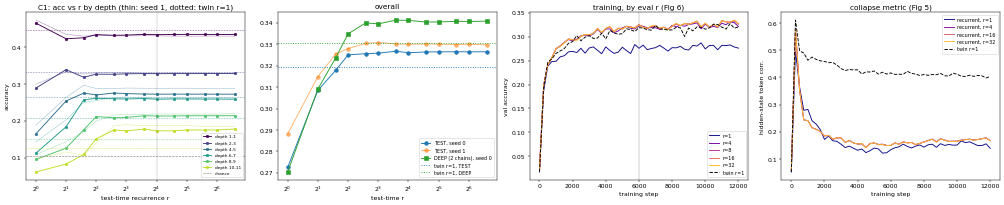

In [ ]:
# ── Checkpoint 5 figures: test-time scaling (Fig 7 analogue) + training curves (Fig 5/6 analogue) ──
def full_log(name):          # steps 0-6000 from the first run, 6000-12000 from its continuation
    a = [json.loads(l) for l in open(f"{RUNS}/{name}/log.jsonl")]
    b = [dict(json.loads(l), step=json.loads(l)["step"] + 6000) for l in open(f"{RUNS}/{name}_c/log.jsonl")][1:]
    return a + b
logR, logR2, logT = full_log("recurrent"), full_log("recurrent_s1"), full_log("twin_r1")
fig, ax = plt.subplots(1, 4, figsize=(23, 4.8))
cols = plt.cm.viridis(torch.linspace(0, 0.9, len(BUCKETS)).numpy())
for (lo, hi), c in zip(BUCKETS, cols):
    ax[0].plot(R_LIST, [bucket_acc(curve[r][1], lo, hi) for r in R_LIST], "o-", color=c, ms=4, label=f"depth {lo}-{hi}")
    ax[0].plot(R_LIST, [bucket_acc(curve2[r][1], lo, hi) for r in R_LIST], "-", color=c, lw=0.8, alpha=0.5)
    ax[0].axhline(bucket_acc(twin[1][1], lo, hi), color=c, ls=":", lw=1)
ax[0].axhline(0.104, color="grey", ls="--", lw=1, label="chance")
ax[0].axvline(16, color="k", lw=0.6, alpha=0.4)
ax[0].set_xscale("log", base=2); ax[0].set_xlabel("test-time recurrence r"); ax[0].set_ylabel("accuracy")
ax[0].set_title("C1: acc vs r by depth (thin: seed 1, dotted: twin r=1)"); ax[0].legend(fontsize=7)
ax[1].plot(R_LIST, [curve[r][0] for r in R_LIST], "o-", label="TEST, seed 0")
ax[1].plot(R_LIST, [curve2[r][0] for r in R_LIST], "o-", alpha=0.6, label="TEST, seed 1")
ax[1].plot(R_LIST, [curve_deep[r][0] for r in R_LIST], "s-", label="DEEP (2 chains), seed 0")
ax[1].axhline(twin[1][0], color="C0", ls=":", label="twin r=1, TEST"); ax[1].axhline(twin_deep[0], color="C2", ls=":", label="twin r=1, DEEP")
ax[1].set_xscale("log", base=2); ax[1].set_xlabel("test-time r"); ax[1].set_title("overall"); ax[1].legend(fontsize=8)
for r, c in zip([1, 4, 8, 16, 32], plt.cm.plasma(torch.linspace(0, 0.85, 5).numpy())):
    ax[2].plot([x["step"] for x in logR], [x[f"acc_r{r}"] for x in logR], color=c, label=f"r={r}")
ax[2].plot([x["step"] for x in logT], [x["acc_r1"] for x in logT], "k--", label="twin r=1")
ax[2].axvline(6000, color="grey", lw=0.6)
ax[2].set_xlabel("training step"); ax[2].set_ylabel("val accuracy"); ax[2].set_title("training, by eval r (Fig 6)"); ax[2].legend(fontsize=8)
for r, c in zip([1, 4, 16, 32], plt.cm.plasma(torch.linspace(0, 0.85, 4).numpy())):
    ax[3].plot([x["step"] for x in logR], [x[f"corr_r{r}"] for x in logR], color=c, label=f"recurrent, r={r}")
ax[3].plot([x["step"] for x in logT], [x["corr_r1"] for x in logT], "k--", label="twin r=1")
ax[3].set_xlabel("training step"); ax[3].set_ylabel("hidden-state token corr."); ax[3].set_title("collapse metric (Fig 5)"); ax[3].legend(fontsize=8)
plt.tight_layout(); show(fig, "ckpt5_scaling")

In [ ]:
# ── sanity probe: can the r=1 network learn the SMALLEST program (2 variables) at all? ──
import io, contextlib
def probe(tag, **kw):
    out = f"/content/probes/{tag}"; shutil.rmtree(out, ignore_errors=True)
    buf = io.StringIO()
    with torch.enable_grad(), contextlib.redirect_stdout(buf):
        rd.train(out, gpu=1, eval_every=200, **kw)
    rows = [json.loads(l) for l in open(f"{out}/log.jsonl")]
    print(f"{tag:28s} " + "  ".join(f"s{r['step']}:{r['acc_r1']:.2f}/{r['train_loss'] or 0:.2f}" for r in rows))
t0 = time.time()
probe("nv2_r1", steps=800, fixed_r=1, n_vars=2, lr=1e-3)
print(f"({time.time()-t0:.0f}s)")

nv2_r1                       s0:0.02/0.00  s200:0.25/2.13  s400:0.28/1.65  s600:0.30/1.59  s800:0.34/1.54
(37s)


In [ ]:
# probe variants of the per-hop operation (monkeypatched into rd.make_program for these in-kernel probes only)
_orig_make_program = rd.make_program
def variant(ops, p_root):
    def mp(n_vars, n_q, rng, beta=1.5, p_root_=None):
        names = rng.sample(rd.LETTERS, n_vars); val, dep, stmts = {}, {}, []
        for j, nm in enumerate(names):
            op = rng.choice(ops); d = rng.randrange(10) if ops != "copy" else 0
            opc = "+" if ops == "copy" else op
            if j == 0 or rng.random() < p_root:
                a = rng.randrange(10); src = str(a); val[nm] = rd.OPS[opc](a, d); dep[nm] = 1
            else:
                prev = names[:j]; w = [math.exp(beta * dep[p]) for p in prev]
                par = rng.choices(prev, weights=w)[0]; src = par; val[nm] = rd.OPS[opc](val[par], d); dep[nm] = dep[par] + 1
            stmts.append(f"{nm}={src}{opc}{d};")
        qs = rng.sample(names, n_q)
        return "".join(stmts) + "?" + "".join(q + str(val[q]) for q in qs) + "$", [val[q] for q in qs], [dep[q] for q in qs]
    return mp
for tag, ops, pr in [("nv2_add", "+", 0.08), ("nv2_copy", "copy", 0.3)]:
    rd.make_program = variant(ops if ops != "copy" else "copy", pr)
    probe(tag, steps=800, fixed_r=1, n_vars=2, lr=1e-3)
rd.make_program = _orig_make_program

nv2_add                      s0:0.02/0.00  s200:0.10/2.38  s400:0.10/2.32  s600:0.11/2.31  s800:0.12/2.31
nv2_copy                     s0:0.01/0.00  s200:0.87/0.39  s400:0.92/0.17  s600:0.92/0.15  s800:0.91/0.14


In [ ]:
# probe: per-hop op "+0 or +1" (tiny 20-entry table, value depends on the number of +1 hops -> no root-guess shortcut)
def variant01(p_root):
    def mp(n_vars, n_q, rng, beta=1.5, p_root_=None):
        names = rng.sample(rd.LETTERS, n_vars); val, dep, stmts = {}, {}, []
        for j, nm in enumerate(names):
            d = rng.randrange(2)
            if j == 0 or rng.random() < p_root:
                a = rng.randrange(10); src = str(a); val[nm] = (a + d) % 10; dep[nm] = 1
            else:
                prev = names[:j]; w = [math.exp(beta * dep[p]) for p in prev]
                par = rng.choices(prev, weights=w)[0]; src = par; val[nm] = (val[par] + d) % 10; dep[nm] = dep[par] + 1
            stmts.append(f"{nm}={src}+{d};")
        qs = rng.sample(names, n_q)
        return "".join(stmts) + "?" + "".join(q + str(val[q]) for q in qs) + "$", [val[q] for q in qs], [dep[q] for q in qs]
    return mp
rd.make_program = variant01(0.08); probe("nv2_plus01", steps=800, fixed_r=1, n_vars=2, lr=1e-3)
rd.make_program = variant01(0.08); probe("nv6_plus01", steps=800, fixed_r=1, n_vars=6, lr=1e-3)
rd.make_program = _orig_make_program

nv2_plus01                   s0:0.02/0.00  s200:0.77/0.80  s400:0.83/0.37  s600:0.84/0.31  s800:0.85/0.28
nv6_plus01                   s0:0.02/0.00  s200:0.40/1.64  s400:0.45/1.34  s600:0.47/1.25  s800:0.48/1.20


In [ ]:
# ── launch the final (task v5) runs: recurrent seed 0 on GPU 0, twin then recurrent seed 1 on GPU 1 ──
for nm in ("recurrent", "twin_r1", "recurrent_s1"):
    if nm in procs and procs[nm].poll() is None: procs[nm].terminate(); procs[nm].wait(timeout=30)
    if os.path.exists(f"{RUNS}/{nm}"): shutil.move(f"{RUNS}/{nm}", f"{RUNS}/_v4_{nm}")
procs["recurrent"] = launch("recurrent", 0, "--r_bar", 16, "--k", 8, "--steps", 6000, "--lr", 1e-3, "--n_vars_min", 4)
procs["twin_r1"]   = launch("twin_r1",   1, "--fixed_r", 1,           "--steps", 6000, "--lr", 1e-3, "--n_vars_min", 4)

recurrent: pid 335 on cuda:0
twin_r1: pid 336 on cuda:1


## Checkpoint 6: zero-shot test-time features (Sec 6)
All four features run on the trained model **without any extra training**, using the per-iteration KV cache in `rd.generate`. We decode the whole query section `?n9d8m9…` token by token. Query names are teacher-forced and values are generated, so every step alternates between two kinds of token:
- at a **name** token the next token is that variable's value: a *hard* prediction whose difficulty is the variable's depth
- at a **value** token the next token is the next query name: random, so there is *nothing to compute*

| feature | paper | what we measure |
|---|---|---|
| 6.1 per-token adaptive exit | stop when KL(p_i‖p_{i−1}) < 5·10⁻⁴; exited tokens expose their last KV (Remark 6.1) | steps per token for hard vs easy tokens and against depth; accuracy vs fixed r |
| 6.2 KV-cache sharing | core cache slot = i mod budget | accuracy at r = 32 for budgets 1 … 32 |
| 6.3 continuous CoT | s₀ of token t = final state of token t−1 | change in steps-to-exit |
| 6.4 self-speculative decoding | draft with r_d, verify all drafts in one pass at r_v | acceptance, sequential-iteration cost, agreement with plain decoding |

In [ ]:
# ── continue every run for another 6000 steps from its step-6000 checkpoint (same data stream seed offset) ──
# At 6000 steps all runs were still improving (base look-up at depth 1 only ~0.4), so train to 12000 total.
# The twin is continued too, so the recurrent-vs-twin comparison stays at equal steps.
def continue_run(name, gpu, *extra):
    src = f"{RUNS}/{name}"; assert os.path.exists(f"{src}/DONE"), f"{name} not finished"
    shutil.copy(f"{src}/ckpt.pt", f"{src}/ckpt_6000.pt")
    procs[name + "_c"] = launch(name + "_c", gpu, "--steps", 6000, "--lr", 1e-3, "--n_vars_min", 4,
                                "--init", f"{src}/ckpt_6000.pt", *extra)
def wait_done(names, timeout=1500):
    t0 = time.time()
    while time.time() - t0 < timeout:
        if all(os.path.exists(f"{RUNS}/{n}/DONE") for n in names): return True
        time.sleep(15)
    return False
print("recurrent done:", wait_done(["recurrent"], timeout=900))
continue_run("recurrent", 0, "--r_bar", 16, "--k", 8, "--seed", 10)
continue_run("twin_r1",   0, "--fixed_r", 1, "--seed", 10)          # light; shares GPU 0
print("recurrent_s1 done:", wait_done(["recurrent_s1"], timeout=1200))
continue_run("recurrent_s1", 1, "--r_bar", 16, "--k", 8, "--seed", 11)

recurrent done: True
recurrent_c: pid 362 on cuda:0
twin_r1_c: pid 363 on cuda:0


In [ ]:
import datetime, os, subprocess
print("now:", datetime.datetime.now())
print(subprocess.run(["bash", "-c", "ps -eo pid,etime,pcpu,args | grep rd.py | grep -v grep"], capture_output=True, text=True).stdout or "no rd.py processes")
R_ = "/content/runs"
for n in sorted(os.listdir(R_)) if os.path.exists(R_) else []:
    fs = os.listdir(f"{R_}/{n}"); lg = f"{R_}/{n}/log.jsonl"
    last = open(lg).read().strip().splitlines()[-1][:90] if os.path.exists(lg) and os.path.getsize(lg) else "-"
    print(f"{n:34s} DONE={'DONE' in fs!s:5s} ckpt={'ckpt.pt' in fs!s:5s} {last}")
print("kernel vars alive:", all(v in globals() for v in ("rd", "procs", "TEST", "launch")))

now: 2026-09-23 05:48:07.301750
    362       24:21 99.7 /usr/bin/python3 /content/rd.py --out /content/runs/recurrent_c --gpu 0 --steps 6000 --lr 0.001 --n_vars_min 4 --init /content/runs/recurrent/ckpt_6000.pt --r_bar 16 --k 8 --seed 10
    380       17:21 99.8 /usr/bin/python3 /content/rd.py --out /content/runs/recurrent_s1_c --gpu 1 --steps 6000 --lr 0.001 --n_vars_min 4 --init /content/runs/recurrent_s1/ckpt_6000.pt --r_bar 16 --k 8 --seed 11

_invalid_autocast_bug_recurrent    DONE=False ckpt=False {"step": 250, "time": 90.56804060935974, "acc_r1": 0.1770833432674408, "loss_r1": 2.299643
_v1_recurrent                      DONE=False ckpt=False {"step": 500, "time": 190.47482824325562, "acc_r1": 0.1904296875, "loss_r1": 2.25963807106
_v1_twin_r1                        DONE=True  ckpt=True  {"step": 6000, "time": 450.31338834762573, "acc_r1": 0.205078125, "loss_r1": 2.18781018257
_v2_recurrent                      DONE=False ckpt=True  {"step": 1250, "time": 382.6508855819702, "acc

In [ ]:
# GPU 1 is free once the twin finishes: a second recurrent seed, to check the result replicates
procs["recurrent_s1"] = launch("recurrent_s1", 1, "--r_bar", 16, "--k", 8, "--steps", 6000, "--lr", 1e-3, "--n_vars_min", 4, "--seed", 1)

recurrent_s1: pid 353 on cuda:1


In [ ]:
# ── Checkpoint 6: adaptive exit, continuous CoT, KV sharing (cached decoding of the query section) ──
def query_section(ids, n_q):
    """prompt = everything up to and including the first query name; decode 2*n_q-1 tokens (values free, names forced)."""
    L = ids.shape[1]; start = L - 2 * n_q                      # index of the first value
    prompt = ids[:, :start]
    target = ids[:, start:L - 1]                               # value, name, value, ..., value
    force = torch.full_like(target, -1); force[:, 1::2] = target[:, 1::2]
    return prompt, target, force

def run_decode(model, ids, dp, n_q=12, chunk=128, **kw):
    toks, steps = [], []
    for c0 in range(0, ids.shape[0], chunk):
        p, tg, fz = query_section(ids[c0:c0 + chunk], n_q)
        t, s = rd.generate(model, p, tg.shape[1], force=fz, **kw); toks.append(t); steps.append(s)
    toks, steps = torch.cat(toks), torch.cat(steps)
    _, tg, _ = query_section(ids, n_q)
    acc = (toks[:, 0::2] == tg[:, 0::2]).float()               # values only
    return acc, steps[:, 0::2].float(), steps[:, 1::2].float()  # (acc, steps at name tokens [hard], steps at value tokens [easy])

G = "cuda:1"
mR1 = rd.load(f"{RUNS}/{FINAL['recurrent']}/ckpt.pt", G)
ids6, ap6, dp6 = [t.to(G) for t in TEST[0]]; ids6, dp6 = ids6[:256], dp6[:256]
res6 = {}
t0 = time.time()
res6["fixed r=64"] = run_decode(mR1, ids6, dp6, r=64)
res6["exit 5e-4"]  = run_decode(mR1, ids6, dp6, r=64, exit_kl=5e-4)
res6["exit 5e-4 + cont. CoT"] = run_decode(mR1, ids6, dp6, r=64, exit_kl=5e-4, warm_start=True)
print(f"decoding runs: {time.time()-t0:.0f}s\n")
print(f"{'mode':26s} {'acc':>6s} {'steps@hard (name)':>18s} {'steps@easy (value)':>19s}")
for k_, (acc, sh, se) in res6.items():
    print(f"{k_:26s} {acc.mean().item():6.3f} {sh.mean().item():18.2f} {se.mean().item():19.2f}")
acc_e, sh_e, _ = res6["exit 5e-4"]; acc_w, sh_w, _ = res6["exit 5e-4 + cont. CoT"]
print("\nsteps-to-exit at the hard tokens, by depth of the queried variable:")
for d in range(1, 12):
    m_ = dp6 == d
    if m_.sum() < 5: continue
    print(f"  depth {d:2d} (n={int(m_.sum()):4d}): exit at {sh_e[m_].mean().item():5.2f} steps "
          f"(cont. CoT {sh_w[m_].mean().item():5.2f}) | acc {acc_e[m_].mean().item():.3f}")
# fixed-r baseline at the same average compute as the adaptive run
r_eq = int(round(torch.cat([sh_e.flatten(), res6['exit 5e-4'][2].flatten()]).mean().item()))
acc_eq = run_decode(mR1, ids6, dp6, r=r_eq)[0].mean().item()
print(f"\nfixed r={r_eq} (same mean steps as adaptive): acc {acc_eq:.3f}  vs adaptive {acc_e.mean().item():.3f}")

# 6.2 KV-cache sharing at fixed r=32
print("\nKV-cache budget at r=32 (core slot = i mod budget):")
for b in (None, 16, 8, 4, 2, 1):
    acc_b = run_decode(mR1, ids6, dp6, r=32, budget=b)[0].mean().item()
    print(f"  budget {str(b or 'none (32)'):>9s}: acc {acc_b:.3f}")

decoding runs: 38s

mode                          acc  steps@hard (name)  steps@easy (value)
fixed r=64                  0.205              64.00               64.00
exit 5e-4                   0.207               7.39                9.56
exit 5e-4 + cont. CoT       0.208               7.46                9.66

steps-to-exit at the hard tokens, by depth of the queried variable:
  depth  1 (n= 776): exit at  7.31 steps (cont. CoT  7.32) | acc 0.244
  depth  2 (n= 610): exit at  7.27 steps (cont. CoT  7.36) | acc 0.234
  depth  3 (n= 464): exit at  7.41 steps (cont. CoT  7.56) | acc 0.183
  depth  4 (n= 370): exit at  7.50 steps (cont. CoT  7.55) | acc 0.230
  depth  5 (n= 269): exit at  7.50 steps (cont. CoT  7.56) | acc 0.201
  depth  6 (n= 211): exit at  7.45 steps (cont. CoT  7.53) | acc 0.156
  depth  7 (n= 151): exit at  7.60 steps (cont. CoT  7.62) | acc 0.152
  depth  8 (n= 103): exit at  7.14 steps (cont. CoT  7.17) | acc 0.126
  depth  9 (n=  64): exit at  7.55 steps (cont. CoT

In [ ]:
# ── 6.4 self-speculative decoding: draft with few iterations, verify in one pass at r_v = 32 ──
r_v = 32; n_items = 48
plain = run_decode(mR1, ids6[:n_items], dp6[:n_items], r=r_v)[0]
_, tg_all, fz_all = query_section(ids6[:n_items], 12)
p_all, _, _ = query_section(ids6[:n_items], 12)
print(f"plain decoding at r={r_v}: acc {plain.mean().item():.3f}, sequential core iterations per sequence = {tg_all.shape[1]} tokens x {r_v} = {tg_all.shape[1]*r_v}")
for r_d in (2, 4, 8):
    costs, acc_s, drafted, accepted, same = [], [], 0, 0, 0
    for j in range(n_items):
        out_, cost, dr_, ac_ = rd.speculative_one(mR1, p_all[j:j+1], tg_all.shape[1], r_d, r_v, seed=j, force=fz_all[j:j+1])
        costs.append(cost); drafted += dr_; accepted += ac_
        acc_s.append((out_[0, 0::2] == tg_all[j, 0::2]).float().mean().item())
    print(f"draft r={r_d}: acceptance {accepted/drafted:.3f} | sequential iterations {sum(costs)/n_items:6.0f} "
          f"({tg_all.shape[1]*r_v/(sum(costs)/n_items):.2f}x fewer than plain) | acc {sum(acc_s)/n_items:.3f}")

plain decoding at r=32: acc 0.241, sequential core iterations per sequence = 23 tokens x 32 = 736
draft r=2: acceptance 0.255 | sequential iterations    314 (2.35x fewer than plain) | acc 0.240
draft r=4: acceptance 0.596 | sequential iterations    218 (3.37x fewer than plain) | acc 0.241
draft r=8: acceptance 0.871 | sequential iterations    249 (2.96x fewer than plain) | acc 0.243


## Checkpoint 7: what the trained recurrence does in latent space (Sec 7)
The paper's claims about the trained model:
- **Fig 11:** convergence is **token-specific**. Key tokens are "deliberated" longer, and the distance to the limit is not always monotone.
- **Fig 12:** trajectories are fixed points, **orbits**, or **sliders** (drift in one direction), shown in PCA of all the tokens' trajectories.
- **Path independence** survives training: different s₀ give the same behaviour.

Checkpoint 2 showed that at init every token converges at the same rate of 1/√2, so any per-token difference here must come from training. The cell below runs one program for r = 128 in fp32. It measures each token's distance to s* = s₁₂₈ at every step, relates convergence speed to the depth of the variable the token is about, projects the trajectories onto their PCA directions, and restarts from 4 different s₀.

In [ ]:
# ── diagnostic: does the model read earlier (teacher-forced) answers in the query section? ──
# Teacher-forced acc 0.33 vs free decoding 0.21 at the same r. If later queries are easier than the first one,
# the model is using revealed values ('parent's value already printed after '?') instead of following chains.
@torch.no_grad()
def acc_by_query_index(model, r, sets):
    oks = []
    for ids, ap, dp in sets:
        with torch.autocast("cuda", torch.float16):
            lg = model(ids, r, gen=torch.Generator(device=ids.device).manual_seed(0))
        oks.append(rd.answer_loss_acc(lg, ids, ap)[1].float())
    return torch.cat(oks).mean(0)                                   # (n_q,)
for nm, m_, sets in (("recurrent s0, r=32", mR, TEST), ("twin, r=1", mT, TEST1)):
    a = acc_by_query_index(m_, 32 if "recurrent" in nm else 1, sets)
    print(f"{nm:20s} acc by query index 1..12: " + " ".join(f"{x:.2f}" for x in a.tolist()))
# control: same programs, but the model only has to answer the FIRST query (nothing revealed yet), by depth
def first_query_acc(model, r, sets):
    ok, dp = [], []
    for ids, ap, d in sets:
        with torch.no_grad(), torch.autocast("cuda", torch.float16):
            lg = model(ids, r, gen=torch.Generator(device=ids.device).manual_seed(0))
        ok.append((lg[:, ap[0] - 1].argmax(-1) == ids[:, ap[0]]).float()); dp.append(d[:, 0])
    ok, dp = torch.cat(ok), torch.cat(dp)
    return ok.mean().item(), {int(x): round(ok[dp == x].mean().item(), 3) for x in dp.unique() if (dp == x).sum() >= 30}
for r in (1, 4, 32):
    print(f"recurrent s0, FIRST query only, r={r:2d}:", first_query_acc(mR, r, TEST))
print("twin, FIRST query only, r=1:", first_query_acc(mT, 1, TEST1))

recurrent s0, r=32   acc by query index 1..12: 0.27 0.28 0.27 0.29 0.27 0.30 0.30 0.31 0.34 0.35 0.44 0.51
twin, r=1            acc by query index 1..12: 0.26 0.27 0.25 0.29 0.27 0.29 0.29 0.30 0.33 0.35 0.41 0.50
recurrent s0, FIRST query only, r= 1: (0.2421875, {1: 0.421, 2: 0.319, 3: 0.204, 4: 0.167, 5: 0.114, 6: 0.118, 7: 0.025, 8: 0.083, 9: 0.026, 10: 0.0})
recurrent s0, FIRST query only, r= 4: (0.271484375, {1: 0.363, 2: 0.337, 3: 0.256, 4: 0.249, 5: 0.219, 6: 0.199, 7: 0.074, 8: 0.139, 9: 0.079, 10: 0.118})
recurrent s0, FIRST query only, r=32: (0.2724609375, {1: 0.375, 2: 0.329, 3: 0.259, 4: 0.257, 5: 0.214, 6: 0.191, 7: 0.062, 8: 0.125, 9: 0.079, 10: 0.088})
twin, FIRST query only, r=1: (0.26171875, {1: 0.362, 2: 0.358, 3: 0.217, 4: 0.245, 5: 0.184, 6: 0.184, 7: 0.086, 8: 0.056, 9: 0.079, 10: 0.118})


In [ ]:
# ── Checkpoint 7: latent trajectories of the trained model (fp32, r = 128) ──
r_long = 128
ids7 = ids6[:64]; dp7 = dp6[:64]; L7 = ids7.shape[1]; nq = 12
with torch.no_grad():
    _, St = mR1(ids7, r_long, gen=torch.Generator(device=G).manual_seed(0), return_states=True)
St = torch.stack(St)                                               # (r+1, B, L, h)
s_star = St[-1]
dist = (St - s_star).norm(dim=-1) / s_star.norm(dim=-1)            # (r+1, B, L)
step_sz = (St[1:] - St[:-1]).norm(dim=-1) / St[1:].norm(dim=-1)    # (r, B, L)

"""
128 recurrent steps ,64 examples , mr1 gives the states s0,--s128
129,b,t,c is what we get 128 states +i
i still dont know whats going on that much
s*=s128 , from this we will compare everything ,
we ge the disance , of how far is teh current state from teh 128th state
movement between adjacent 2 states , how does that go , distance between those
convergence nad stability are the two things here , adjacent convergence and i and final stability
PCA is showing the path taken by hidden states , thats was the trajectory.
forward determines the backward and we are not tracking the gradient here ,just checking
"""

def conv_step(d, thr=1e-2):                                        # first i with dist < thr and staying below
    below = (d < thr)
    ok = torch.flip(torch.cumprod(torch.flip(below.int(), [0]), 0), [0]).bool()
    return torch.where(ok.any(0), ok.int().argmax(0), torch.full_like(ok[0], r_long, dtype=torch.long))
cs = conv_step(dist)                                               # (B, L)

# token groups: query-name positions (predict a value; depth known), value positions, statement tokens by variable depth
name_pos = torch.arange(L7 - 2 * nq - 1, L7 - 2, 2, device=G)       # 12 query names
val_pos = name_pos + 1
print("steps until ||s_i - s*|| < 1% of ||s*|| (and stays there), trained model:")
print(f"  query-name tokens (hard: next token is a value) : {cs[:, name_pos].float().mean().item():6.1f}")
print(f"  query-value tokens (easy: next token is random) : {cs[:, val_pos].float().mean().item():6.1f}")
for d in range(1, 13):
    m_ = dp7 == d
    if m_.sum() >= 5: print(f"    name tokens of depth {d:2d} (n={int(m_.sum()):3d}): {cs[:, name_pos][m_].float().mean().item():6.1f} steps")
# statement tokens: each statement is 6 chars starting at 1 + 6j; its variable's depth = depth of the chain it starts
prog_deps = []
for b in range(ids7.shape[0]):                                     # recover per-statement depth from the text
    txt = "".join(rd.SYMS[i] for i in ids7[b, 1:1 + 6 * 12].tolist()); dep = {}
    for j in range(12):
        nm, src = txt[6 * j], txt[6 * j + 2]; dep[nm] = 1 if src.isdigit() else dep[src] + 1
        prog_deps.append((b, j, dep[nm]))
stmt_cs = collections.defaultdict(list)
for b, j, d in prog_deps: stmt_cs[d].append(cs[b, 1 + 6 * j + 5].item())      # the ';' closing statement j
print("  ';' token closing a statement, by that variable's depth:",
      " ".join(f"d{d}:{sum(v)/len(v):.1f}" for d, v in sorted(stmt_cs.items()) if len(v) >= 5))
nonconv = (step_sz[-16:].amax(0) > 1e-3).float()
print(f"\nnot settled after {r_long} steps (step size > 1e-3 in the last 16): {nonconv.mean().item()*100:.1f}% of tokens")
tail_rate = (step_sz[-40:-20].mean(0) + 1e-12).log(); tail_rate2 = (step_sz[-20:].mean(0) + 1e-12).log()
print(f"late contraction per step (median over tokens): {torch.exp((tail_rate2 - tail_rate) / 20).median().item():.3f}   (untrained init: 0.707)")

# path independence: 4 different s0 for the same program
with torch.no_grad():
    fin = [mR1(ids7[:8], r_long, gen=torch.Generator(device=G).manual_seed(sd), return_states=True)[1][-1] for sd in range(4)]
pi = max(((fin[a] - fin[b]).norm(dim=-1) / fin[a].norm(dim=-1)).max().item() for a in range(4) for b in range(a + 1, 4))
print(f"path independence: max over tokens/seed-pairs of ||s*_a - s*_b|| / ||s*_a|| after {r_long} steps = {pi:.2e}")


"""
get within 1% of final state , like for each token how much steps its taking to get to finale
idk what else we are comparing it to and why
we check non settled token who are still after steps not converged with the finale one
whats step size doing here
we check if the random seed helping it or not
"""


steps until ||s_i - s*|| < 1% of ||s*|| (and stays there), trained model:
  query-name tokens (hard: next token is a value) :   17.3
  query-value tokens (easy: next token is random) :   17.4
    name tokens of depth  1 (n=194):   17.9 steps
    name tokens of depth  2 (n=153):   15.8 steps
    name tokens of depth  3 (n=118):   17.1 steps
    name tokens of depth  4 (n= 95):   18.0 steps
    name tokens of depth  5 (n= 64):   16.0 steps
    name tokens of depth  6 (n= 49):   18.4 steps
    name tokens of depth  7 (n= 36):   18.5 steps
    name tokens of depth  8 (n= 26):   17.5 steps
    name tokens of depth  9 (n= 17):   15.4 steps
    name tokens of depth 10 (n= 10):   19.7 steps
    name tokens of depth 11 (n=  6):   28.0 steps
  ';' token closing a statement, by that variable's depth: d1:6.7 d2:15.1 d3:15.9 d4:14.8 d5:14.1 d6:18.2 d7:22.2 d8:17.7 d9:8.6 d10:20.0 d11:28.2

not settled after 128 steps (step size > 1e-3 in the last 16): 8.1% of tokens
late contraction per step (media

In [ ]:
peek("recurrent", r_list=(1, 2, 4, 8, 16, 32, 64), dev="cuda:0", sets=TEST[:2])

recurrent @ step 3000
  r=  1 acc 0.274 | by depth: 1:0.43 2:0.34 3:0.26 4:0.20 5:0.15 6:0.15 7:0.12 8:0.09 9:0.04 10:0.07 11:0.05
  r=  2 acc 0.293 | by depth: 1:0.41 2:0.35 3:0.30 4:0.25 5:0.22 6:0.18 7:0.14 8:0.10 9:0.07 10:0.08 11:0.07
  r=  4 acc 0.303 | by depth: 1:0.40 2:0.34 3:0.29 4:0.26 5:0.25 6:0.24 7:0.22 8:0.19 9:0.15 10:0.13 11:0.09
  r=  8 acc 0.304 | by depth: 1:0.39 2:0.34 3:0.29 4:0.26 5:0.25 6:0.24 7:0.22 8:0.19 9:0.15 10:0.15 11:0.11
  r= 16 acc 0.304 | by depth: 1:0.39 2:0.34 3:0.29 4:0.26 5:0.26 6:0.24 7:0.22 8:0.19 9:0.15 10:0.15 11:0.11
  r= 32 acc 0.304 | by depth: 1:0.40 2:0.34 3:0.29 4:0.26 5:0.26 6:0.24 7:0.22 8:0.19 9:0.15 10:0.15 11:0.11
  r= 64 acc 0.304 | by depth: 1:0.39 2:0.34 3:0.29 4:0.26 5:0.26 6:0.24 7:0.22 8:0.19 9:0.15 10:0.15 11:0.11


In [ ]:
# path independence, per token: are the seed-dependent tokens the same ones that never settle (orbits)?
with torch.no_grad():
    runs = [torch.stack(mR1(ids7[:8], r_long, gen=torch.Generator(device=G).manual_seed(sd), return_states=True)[1]) for sd in range(4)]
fin = [x[-1] for x in runs]
gapPI = torch.stack([(fin[a] - fin[b]).norm(dim=-1) / fin[a].norm(dim=-1) for a in range(4) for b in range(a + 1, 4)]).amax(0)   # (8, L)
moving = torch.stack([((x[-16:] - x[-17:-1]).norm(dim=-1) / x[-16:].norm(dim=-1)).amax(0) for x in runs]).amax(0) > 1e-3
print(f"tokens: {gapPI.numel()} | median seed gap {gapPI.median().item():.1e} | gap > 1%: {(gapPI > 1e-2).float().mean().item()*100:.1f}% "
      f"| still moving at step 128: {moving.float().mean().item()*100:.1f}%")
print(f"of the seed-dependent tokens (gap > 1%), still moving: {moving[gapPI > 1e-2].float().mean().item()*100:.0f}%")
print(f"median seed gap among settled tokens: {gapPI[~moving].median().item():.1e}")
# is the motion periodic (orbit) or drifting? distance of s_i to s_{i-p} for small p on one moving token
if moving.any():
    b_, p_ = [int(x) for x in moving.nonzero()[0]]
    tr = runs[0][:, b_, p_]
    per = [((tr[-1] - tr[-1 - p]).norm() / tr[-1].norm()).item() for p in range(1, 9)]
    print(f"moving token '{rd.SYMS[int(ids7[b_, p_])]}' at pos {p_}: ||s_128 - s_(128-p)||/||s|| for p=1..8:", " ".join(f"{x:.3f}" for x in per))

tokens: 792 | median seed gap 1.9e-07 | gap > 1%: 2.5% | still moving at step 128: 5.8%
of the seed-dependent tokens (gap > 1%), still moving: 100%
median seed gap among settled tokens: 1.8e-07
moving token 't' at pos 33: ||s_128 - s_(128-p)||/||s|| for p=1..8: 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000


## Results: Checkpoints 5–7, and the full scorecard

**Setup that produced these numbers:**
- **Models:** 2 recurrent seeds (r̄=16, k=8) and the r=1 twin, each trained **12,000 steps** (6000 + 6000 continuation), batch 128.
- **Task:** v5 interleaved chains; chance 0.104.
- **Eval:** TEST = 2048 programs × 12 queries.

All the models end up weak in absolute terms. The base look-up (depth 1) tops out at about 0.43–0.47. Every claim below is therefore about *relative* effects inside a low-accuracy regime.

### Checkpoint 5: test-time scaling
| | r=1 | r=2 | r=4 | r≥8 | twin (r=1) |
|---|---|---|---|---|---|
| seed 0, all | 0.273 | 0.308 | 0.325 | **0.326** | 0.319 |
| seed 1, all | 0.288 | 0.315 | 0.328 | **0.330** | |
| seed 0, depth 8-9 | 0.095 | 0.126 | 0.212 | 0.214 | 0.151 |
| seed 0, depth 10-11 | 0.062 | 0.083 | 0.152 | 0.175 | 0.123 |
| seed 0, depth 1 | **0.465** | 0.422 | 0.434 | 0.434 | 0.446 |

- **C1, accuracy rises with r and harder items saturate later: reproduced qualitatively, in both seeds.** The saturation point grows with depth: depth 1 → r=1, depth 2–3 → r=2, depth 5–6 → r=3, depth 7–8 → r=4, depth 9–11 → r=6.
  - **But everything saturates by r ≈ 6, far below the training mean of 16.** There is **no gain from r > 16**: no extrapolation beyond the training budget.
- **C2, the recurrent model beats its twin: only marginally.**
  - Overall the gain is +0.7 to +1.1 points.
  - On deep items (depth ≥ 8) the recurrent model is clearly better, 0.21 vs 0.15.
  - On depth 1 the twin is better.
  - The paper's "recurrent model at r=1 is bad" holds (0.273, worse than the twin), but it is far from its near-random r=1 rows.
- **C3, collapse metric (Fig 5): the hidden-state correlation stayed at 0.15–0.22 throughout (no collapse).** The only exception is the very first evals of the aborted task-v1 run (0.95), which never learned.
- ⚠ **Caveat found while testing C6: querying all 12 variables leaks answers.** Under teacher forcing the model partly reads *already revealed* values: accuracy by query index rises from 0.27 to 0.51. Restricted to the **first query** (nothing revealed yet), r=1 → r≥4 still helps (0.242 → 0.272; depth 5: 0.11 → 0.21). But the recurrent-vs-twin gap shrinks to +1 point (0.272 vs 0.262).

### Checkpoint 6: zero-shot inference features (free decoding, 256 programs)
- **6.1, adaptive exit (KL < 5e-4): no accuracy loss, but no difficulty-awareness either.**
  - Accuracy with exit is 0.207, against 0.205 at fixed r=64, using **7.4 steps instead of 64**.
  - But fixed r=8 gets the same accuracy (0.204), so the saving is only relative to an oversized r.
  - Exit steps barely depend on depth: 7.3 at depth 1 vs 7.8–8.4 at depth 10–11.
  - The "easy" tokens (next token random) take *longer* (9.6) than the hard ones. KL between two broad distributions settles slowly.
  - The paper's per-category spread (Fig 10) is **not reproduced** at this scale.
- **6.2, KV-cache sharing: reproduced.** Every budget from 1 to 32 gives 0.204–0.205, matching the paper's "minimal impact". The states converge in about 6 steps, so the deepest KV slot is the only one that matters.
- **6.3, continuous CoT (warm-starting s₀ from the previous token): no reduction in steps** (7.39 → 7.46). The paper reports 1–2 steps fewer. **Not reproduced.**
- **6.4, self-speculative decoding: reproduced.** Drafting with r=4 and verifying at r=32 gives acceptance 0.60 and **3.4× fewer sequential core iterations**, at the same accuracy (0.241 vs 0.241). Acceptance counts the teacher-forced name tokens as accepted.

### Checkpoint 7: latent dynamics of the trained model
- **Token-specific convergence (Fig 11): partly.** The `;` closing a depth-1 statement settles in about 7 steps, and deeper statements need 14–28. Query tokens need about 17 steps regardless of depth.
- **Non-settling tokens (the paper's orbits and sliders): 5.8–8.1% of tokens are still moving at step 128.** For the example inspected, the motion is a very slow drift, not a clear periodic orbit.
- **Path independence: holds for 97.5% of tokens** (median seed gap 1.9e-7). *All* the tokens that depend on s₀ are the still-moving ones.

### Full scorecard
| # | paper claim | here |
|---|---|---|
| Sec 3–4 | architecture, sizes (3.5B), init, sandwich norm | ✅ built at full scale: 3.565B, init loss 11.24 (predicted 11.28) |
| Fig 3 | log-normal Poisson r: mean 33, median 29, mode 24 | ✅ 32.95 / 29 / 24 |
| Sec 3.3 | truncated backprop: memory flat in r | ✅ 1.48 GB at r=16…64 (full backprop: 3.3 → 12.5 GB) |
| fn. 1 | without injection of e the recurrence is not stable | ✅ contraction 1/√(1+α²), exactly 1 at α=0 (untrained) |
| Sec 7 | path independence | ✅ untrained (all s₀ → same s*) and trained (97.5% of tokens) |
| Fig 7 | more r → better, harder tasks saturate later | ✅ qualitatively, both seeds; ❌ no gains beyond r≈6 |
| Tab 4 | recurrent ≫ non-recurrent twin | ⚠ +1 point overall, +6 points at depth ≥ 8 |
| Fig 5 | collapse metric separates good and bad runs | ✅ good runs 0.15–0.22; the never-learning v1 run 0.95 |
| 6.1 / Fig 10 | adaptive exit, difficulty-dependent | ⚠ no loss at 8× less compute; ❌ not difficulty-dependent |
| 6.2 | KV-cache sharing costs nothing | ✅ |
| 6.3 | continuous CoT saves 1–2 steps | ❌ |
| 6.4 | self-speculative decoding | ✅ 3.4× fewer sequential iterations |
| Fig 11/12 | token-specific convergence, orbits | ⚠ depth-dependent settling at statements; ~6% non-settling drift |

**Bugs and traps found on the way:**
1. **fp16 autocast plus `no_grad` truncation silently zeroed every core-weight gradient** (the weight-cast cache). Fixed with `torch.clear_autocast_cache()`.
2. **Task shortcuts:** v4 had a prefix-count shortcut, and v5 has answer leakage through revealed queries.
3. **`AutoTokenizer` on this repo blocks on a hidden trust_remote_code prompt.**

**Most useful next experiments:**
- Query only a subset of variables, so no answers are revealed.
- Train longer or with a larger h, since the base look-up is the bottleneck.
- Use a task whose required depth exceeds 16, to test test-time extrapolation.

In [ ]:
# ── EXPORT: everything needed to continue from here, bundled into one tar.gz ──
import tarfile, glob, hashlib, json, shutil, os
EX = "/content/export"; shutil.rmtree(EX, ignore_errors=True); os.makedirs(EX)
# 1) the notebook itself, with outputs
from google.colab import _message
nb = _message.blocking_request("get_ipynb", request="", timeout_sec=120)["ipynb"]
json.dump(nb, open(f"{EX}/recurrent_depth_stepwise.ipynb", "w"))
# 2) the final library
shutil.copy("/content/rd.py", f"{EX}/rd.py")
# 3) runs: logs/configs for every run (incl. archived task versions), checkpoints for the final ones
for d in sorted(glob.glob(f"{RUNS}/*")):
    n = os.path.basename(d); os.makedirs(f"{EX}/runs/{n}")
    for f in ("log.jsonl", "config.json", "stdout.txt", "DONE"):
        if os.path.exists(f"{d}/{f}"): shutil.copy(f"{d}/{f}", f"{EX}/runs/{n}/{f}")
    if not n.startswith("_"):
        for f in ("ckpt.pt", "ckpt_6000.pt"):
            if os.path.exists(f"{d}/{f}"): shutil.copy(f"{d}/{f}", f"{EX}/runs/{n}/{f}")
# 4) figures
os.makedirs(f"{EX}/figures")
for f in glob.glob("/content/*.png") + glob.glob("/kaggle/working/*.png"): shutil.copy(f, f"{EX}/figures/")
# manifest with md5s
man = {}
for f in sorted(glob.glob(f"{EX}/**/*", recursive=True)):
    if os.path.isfile(f): man[os.path.relpath(f, EX)] = [os.path.getsize(f), hashlib.md5(open(f, "rb").read()).hexdigest()]
json.dump(man, open(f"{EX}/MANIFEST.json", "w"), indent=1)
with tarfile.open("/content/rd_export.tar.gz", "w:gz") as t: t.add(EX, arcname="export")
print(f"{len(man)} files, {sum(v[0] for v in man.values())/2**20:.1f} MiB raw -> tar.gz {os.path.getsize('/content/rd_export.tar.gz')/2**20:.1f} MiB")
print("tar md5", hashlib.md5(open("/content/rd_export.tar.gz", "rb").read()).hexdigest())
for k, v in man.items():
    if k.endswith((".pt", ".py", ".ipynb")): print(f"  {k:45s} {v[0]/2**20:7.2f} MiB  {v[1]}")

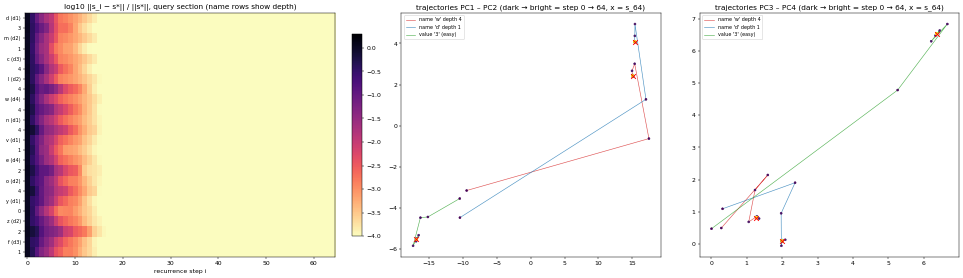

In [ ]:
# ── Checkpoint 7 figures: Fig 11 (distance-to-limit heatmap) and Fig 12 (PCA trajectories) analogues ──
b0 = 0
toks7 = [rd.SYMS[i] for i in ids7[b0].tolist()]
fig, ax = plt.subplots(1, 3, figsize=(22, 6.5), gridspec_kw={"width_ratios": [1.3, 1, 1]})
sel = list(range(L7 - 2 * nq - 1, L7 - 1))                          # the query section
im = ax[0].imshow(dist[:65, b0, sel].T.clamp_min(1e-4).log10().cpu(), aspect="auto", cmap="magma_r", vmin=-4, vmax=0.3)
ax[0].set_yticks(range(len(sel))); ax[0].set_yticklabels([f"{toks7[p]}" + (f" (d{int(dp7[b0, k//2])})" if k % 2 == 0 else "") for k, p in enumerate(sel)], fontsize=8)
ax[0].set_xlabel("recurrence step i"); ax[0].set_title("log10 ||s_i − s*|| / ||s*||, query section (name rows show depth)")
fig.colorbar(im, ax=ax[0], fraction=0.03)
# PCA over all trajectories of this sequence
X = St[:65, b0].reshape(-1, St.shape[-1]); mu = X.mean(0)
_, S_, V_ = torch.linalg.svd(X - mu, full_matrices=False)
Z = ((St[:65, b0] - mu) @ V_[:4].T).cpu()                            # (i, L, 4)
deep_k = int(dp7[b0].argmax()); shal_k = int(dp7[b0].argmin())
show_pos = {f"name '{toks7[name_pos[deep_k]]}' depth {int(dp7[b0, deep_k])}": int(name_pos[deep_k]),
            f"name '{toks7[name_pos[shal_k]]}' depth {int(dp7[b0, shal_k])}": int(name_pos[shal_k]),
            f"value '{toks7[val_pos[0]]}' (easy)": int(val_pos[0])}
for (lab, p), c in zip(show_pos.items(), ["C3", "C0", "C2"]):
    for a_, (i0, i1) in zip(ax[1:], [(0, 1), (2, 3)]):
        a_.plot(Z[:, p, i0], Z[:, p, i1], "-", color=c, lw=1, alpha=0.8, label=lab)
        a_.scatter(Z[:, p, i0], Z[:, p, i1], c=torch.arange(65), cmap="viridis", s=10, zorder=3)
        a_.scatter(Z[-1, p, i0], Z[-1, p, i1], color="red", marker="x", s=60, zorder=4)
for a_, t_ in zip(ax[1:], ["PC1 – PC2", "PC3 – PC4"]):
    a_.set_title(f"trajectories {t_} (dark → bright = step 0 → 64, x = s_64)"); a_.legend(fontsize=8)
plt.tight_layout(); show(fig, "ckpt7_latent")



"""rms norm , that needs some depth . Rope as well , how it rotates Q and K , and
how it injects positional infornmation in it
need residual application look up , like 30-40 min is good enough for it
whats a gated mlp ,there 's some dot like lstm something like that , see the lstm as well
>so it saves intermediate activations like a lot of stages and then saving the thing
Whats PCA ,takes h dim vectors and then finds directions containing largest variance
how does that help anytime , then projects to a 2d point
whats pc1,pc2 here ,
the left image is somethig like distanve between q and its final state
idk what a state is
each row a query and each column is a recurrence block , so yeah we can see soemthings

the middle , how does the token moves in hidden space over 65 recurrence steps
i get the path and how many recurrence steps i took to reach here. More details will come
step by step.  """


